# 환경설정  

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', 100) 
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', '{:.2f}'.format)

import matplotlib as mpl

# 한글 폰트 설정 (윈도우용 기본 설정)
plt.rcParams['font.family'] = 'Malgun Gothic'  # 또는 'AppleGothic' (macOS)
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 깨짐 방지

In [2]:
# 환경 설정
# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'  # 나눔고딕 폰트 사용
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

# 폰트가 없을 경우 대비한 예외 처리
try:
    plt.rc('font', family='NanumGothic')
except:
    # 나눔고딕 폰트가 없으면 시스템의 기본 한글 폰트 찾기
    for font in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
        try:
            font_name = fm.FontProperties(fname=font).get_name()
            if any(kor in font_name for kor in ['Gothic', '돋움', '굴림', '바탕']):
                plt.rc('font', family=font_name)
                break
        except:
            pass

In [3]:
#csv 불러오기   
df_original = pd.read_csv(r"C:\Users\장정근\OneDrive\바탕 화면\accepted_2007_to_2018q4.csv\accepted_2007_to_2018Q4.csv") #승인된 대출 정보

#데이터 행,열 개수 파악
df_original.shape

C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\3645188709.py:2: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  df_original = pd.read_csv(r"C:\Users\장정근\OneDrive\바탕 화면\accepted_2007_to_2018q4.csv\accepted_2007_to_2018Q4.csv") #승인된 대출 정보


(2260701, 151)

# 결측치가 전체데이터의 50%가 넘는 컬럼 삭제  

In [4]:
# 결측치 비율(%) 계산
missing_ratio = df_original.isnull().mean() *100
missing_ratio

# 결측치 비율이 50% 이상인 컬럼
over_missing_ratio = missing_ratio[missing_ratio >= 50].index.tolist()
over_missing_ratio

# 결측치 50% 넘는 컬럼 제거 -> 새로운 df1
df_cleaned = df_original.drop(columns=over_missing_ratio)
df_cleaned

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,policy_code,...,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
0,68407277,3600.00,3600.00,3600.00,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.00,Aug-2003,675.00,679.00,1.00,7.00,0.00,2765.00,29.70,13.00,w,0.00,0.00,4421.72,4421.72,3600.00,821.72,0.00,0.00,0.00,Jan-2019,122.67,Mar-2019,564.00,560.00,0.00,1.00,...,1.00,21.00,4981.00,36.00,3.00,3.00,722.00,34.00,9300.00,3.00,1.00,4.00,4.00,20701.00,1506.00,37.20,0.00,0.00,148.00,128.00,3.00,3.00,1.00,4.00,4.00,2.00,2.00,4.00,2.00,5.00,3.00,4.00,9.00,4.00,7.00,0.00,0.00,0.00,3.00,76.90,0.00,0.00,0.00,178050.00,7746.00,2400.00,13734.00,N,Cash,N
1,68355089,24700.00,24700.00,24700.00,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,small_business,Business,577xx,SD,16.06,1.00,Dec-1999,715.00,719.00,4.00,22.00,0.00,21470.00,19.20,38.00,w,0.00,0.00,25679.66,25679.66,24700.00,979.66,0.00,0.00,0.00,Jun-2016,926.35,Mar-2019,699.00,695.00,0.00,1.00,...,1.00,19.00,18005.00,73.00,2.00,3.00,6472.00,29.00,111800.00,0.00,0.00,6.00,4.00,9733.00,57830.00,27.10,0.00,0.00,113.00,192.00,2.00,2.00,4.00,2.00,0.00,0.00,5.00,5.00,13.00,17.00,6.00,20.00,27.00,5.00,22.00,0.00,0.00,0.00,2.00,97.40,7.70,0.00,0.00,314017.00,39475.00,79300.00,24667.00,N,Cash,N
2,68341763,20000.00,20000.00,20000.00,60 months,10.78,432.66,B,B4,truck driver,10+ years,MORTGAGE,63000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,home_improvement,NaN,605xx,IL,10.78,0.00,Aug-2000,695.00,699.00,0.00,6.00,0.00,7869.00,56.20,18.00,w,0.00,0.00,22705.92,22705.92,20000.00,2705.92,0.00,0.00,0.00,Jun-2017,15813.30,Mar-2019,704.00,700.00,0.00,1.00,...,4.00,19.00,10827.00,73.00,0.00,2.00,2081.00,65.00,14000.00,2.00,5.00,1.00,6.00,31617.00,2737.00,55.90,0.00,0.00,125.00,184.00,14.00,14.00,5.00,101.00,10.00,0.00,2.00,3.00,2.00,4.00,6.00,4.00,7.00,3.00,6.00,0.00,0.00,0.00,0.00,100.00,50.00,0.00,0.00,218418.00,18696.00,6200.00,14877.00,N,Cash,N
3,66310712,35000.00,35000.00,35000.00,60 months,14.85,829.90,C,C5,Information Systems Officer,10+ years,MORTGAGE,110000.00,Source Verified,Dec-2015,Current,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,076xx,NJ,17.06,0.00,Sep-2008,785.00,789.00,0.00,13.00,0.00,7802.00,11.60,17.00,w,15897.65,15897.65,31464.01,31464.01,19102.35,12361.66,0.00,0.00,0.00,Feb-2019,829.90,Mar-2019,679.00,675.00,0.00,1.00,...,1.00,23.00,12609.00,70.00,1.00,1.00,6987.00,45.00,

# 대출 상태(loan_status)를 상환/미상환 2가지로 분류 (fully paid or Charged off,DEfault)

In [5]:
#대출 상태(분석대상 변수, y)를 Fully Paid / Charged Off, Default 만 남기고 제거
df_filtered=df_cleaned[df_cleaned['loan_status'].isin(['Fully Paid', 'Charged Off', 'Default'])].copy()

#분류분석이므로 2개의 클래스로 나누기
df_filtered['target'] = df_filtered['loan_status'].apply(lambda x: 1 if x =='Fully Paid' else 0)

#0 상환 실패(미상환) 1 상환(Fully Paid) 
df_filtered['target']
df_filtered.shape

(1345350, 108)

# 결측치 있는 컬럼 기준에 따라 결측치 처리

In [6]:
#emp_title 대출자 직업 의 결측치 -> Unknown 으로 치환
df_filtered['emp_title'].value_counts
df_filtered['emp_title'] = df_filtered['emp_title'].fillna('Unknown')
df_filtered['emp_title'].value_counts()

#emp_length 고용기간 의 결측치 -> Unknown 으로 치환
df_filtered['emp_length'].value_counts
df_filtered['emp_length'] = df_filtered['emp_length'].fillna('Unknown')
df_filtered['emp_length'].value_counts()

#dti 부채 대비 소득 비율  -> 중앙값으로 대체
# df_filtered['dti'].info()
median_dti = df_filtered['dti'].median()
df_filtered['dti'] = df_filtered['dti'].fillna(median_dti)

#revol_util 리볼빙 대출 사용률(%) -> 중앙값으로 대체
median_revol_util = df_filtered['revol_util'].median()
df_filtered['revol_util'] = df_filtered['revol_util'].fillna(median_revol_util)

In [7]:
df_filtered['dti'].describe()

count   1345350.00
mean         18.28
std          11.16
min          -1.00
25%          11.79
50%          17.61
75%          24.05
max         999.00
Name: dti, dtype: float64

# df_main 로 카피해서 이상치 제거 (팀원들과 종합하기 용이하게 이름 통일)

In [8]:
df_main = df_filtered.copy()

# 이상치 제거

## 1.연속형

In [9]:
#loan_amnt 로그변환
df_main['loan_amnt'] = np.log1p(df_main['loan_amnt'])

# int_rate 클리핑 적용
df_main['int_rate'] = df_main['int_rate'].clip(upper=26.30)

#installment 클리핑 적용

df_main['installment'] = df_filtered['installment'].clip(upper=1221.5)

# 1. 'fico_range_high'와 'open_acc'는 IQR 방식으로 이상치 제거
for col in ['fico_range_high', 'open_acc','revol_bal']:
    Q1 = df_main[col].quantile(0.25)
    Q3 = df_main[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_main = df_main[(df_main[col] >= lower_bound) & (df_main[col] <= upper_bound)]

# 2. 'revol_bal'은 로그변환 후 IQR 이상치 제거
df_main['revol_bal_log'] = np.log1p(df_main['revol_bal']) #로그변환

Q1 = df_main['revol_bal_log'].quantile(0.25)
Q3 = df_main['revol_bal_log'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_main = df_main[(df_main['revol_bal_log'] >= lower_bound) & (df_main['revol_bal_log'] <= upper_bound)]


#annual_inc 연간소득 -> IQR 이상치 제거
Q1 = df_main['annual_inc'].quantile(0.25)
Q3 = df_main['annual_inc'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask = (df_main['annual_inc'] < lower_bound) | (df_main['annual_inc'] > upper_bound)

#이상치 제거 :annual_inc 컬럼의 이상치가 아닌 행만 남김
df_main = df_main[~mask]

#dti 부채 대비 소득비율 -> z-score 
dti_df = df_main[['dti']].copy()
from sklearn.preprocessing import StandardScaler
dti_df['zscore'] = StandardScaler().fit_transform(dti_df[['dti']])
mask = (dti_df['zscore'] < -3) | (dti_df['zscore'] > 3)

#이상치 제거
df_main = df_main.loc[~mask]


#fico_range_low FICO 신용점수 -> IQR
Q1 = df_main['fico_range_low'].quantile(0.25)
Q3 = df_main['fico_range_low'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask = (df_main['fico_range_low'] < lower_bound) | (df_main['fico_range_low'] > upper_bound)

#이상치 제거
df_main = df_main[~mask]

#total_acc 연간소득 -> IQR 이상치 제거

Q1 = df_main['total_acc'].quantile(0.25)
Q3 = df_main['total_acc'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask = (df_main['total_acc'] < lower_bound) | (df_main['total_acc'] > upper_bound)
print('IQR 기준 total_acc 이상치 수:', mask.sum())

#이상치 제거 :total_acc 컬럼의 이상치가 아닌 행만 남김
df_main = df_main[~mask]

#revol_util iqr 이상치 처리
Q1 = df_main['revol_util'].quantile(0.25)
Q3 = df_main['revol_util'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
mask = (df_main['revol_util'] < lower_bound) | (df_main['revol_util'] > upper_bound)
print('IQR 기준 revol_util 이상치 수:', mask.sum())

#이상치 제거 :revol_util 컬럼의 이상치가 아닌 행만 남김
df_main = df_main[~mask]


IQR 기준 total_acc 이상치 수: 18028
IQR 기준 revol_util 이상치 수: 67


## 2.명목형

In [10]:
#emp_title(직업) 컬럼 삭제
df_main = df_main.drop(columns=['emp_title'])

#emp_length_order 순서형 인코딩
emp_length_order = {
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10,
    'unknown': -1
}

df_main['emp_length'] = df_main['emp_length'].map(emp_length_order)

#purpose
#top2(debt_consolidation, credit_card) + others(컬럼3개)
purpose_rate=df_main['purpose'].value_counts(normalize=True) * 100
purpose_rate.sort_values(ascending=False)
others = ['home_improvement','other','medical','major_purchase','small_business','car','moving','vacation','house', 'wedding','renewable_energy', 'educational']
df_main['purpose'] = df_main['purpose'].apply(lambda x : 'others' if x in others else x)


#sub_grade 이상치 처리
df_cleaned = df_main['sub_grade'].copy()
value_counts = df_cleaned.value_counts(normalize=True)
rare_values = value_counts[value_counts < 0.01]

# 희귀값 인덱스를 가진 행을 제거
df_main = df_main[~df_main['sub_grade'].isin(rare_values)]

# 파생 변수 생성

In [11]:
# loan_to_income 파생 변수 생성: 대출금액 / 연소득
df_main['loan_to_income'] = df_main['loan_amnt'] / df_main['annual_inc']

In [12]:
# fico_mean 평균 컬럼 생성 -> 나머지는 없앰
df_main['fico_mean'] = (df_main['fico_range_high'] + df_main['fico_range_low']) / 2
df_main = df_main.drop(['fico_range_low', 'fico_range_high'], axis=1)

# grade drop -> sub grade만 사용
df_main.drop('grade', axis=1)

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,...,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,target,revol_bal_log,loan_to_income,fico_mean
0,68407277,8.19,3600.00,3600.00,36 months,13.99,123.03,C4,10.00,MORTGAGE,55000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.00,Aug-2003,1.00,7.00,0.00,2765.00,29.70,13.00,w,0.00,0.00,4421.72,4421.72,3600.00,821.72,0.00,0.00,0.00,Jan-2019,122.67,Mar-2019,564.00,560.00,0.00,1.00,Individual,0.00,722.00,144904.00,...,3.00,3.00,722.00,34.00,9300.00,3.00,1.00,4.00,4.00,20701.00,1506.00,37.20,0.00,0.00,148.00,128.00,3.00,3.00,1.00,4.00,4.00,2.00,2.00,4.00,2.00,5.00,3.00,4.00,9.00,4.00,7.00,0.00,0.00,0.00,3.00,76.90,0.00,0.00,0.00,178050.00,7746.00,2400.00,13734.00,N,Cash,N,1,7.93,0.00,677.00
1,68355089,10.11,24700.00,24700.00,36 months,11.99,820.28,C1,10.00,MORTGAGE,65000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,others,Business,577xx,SD,16.06,1.00,Dec-1999,4.00,22.00,0.00,21470.00,19.20,38.00,w,0.00,0.00,25679.66,25679.66,24700.00,979.66,0.00,0.00,0.00,Jun-2016,926.35,Mar-2019,699.00,695.00,0.00,1.00,Individual,0.00,0.00,204396.00,...,2.00,3.00,6472.00,29.00,111800.00,0.00,0.00,6.00,4.00,9733.00,57830.00,27.10,0.00,0.00,113.00,192.00,2.00,2.00,4.00,2.00,0.00,0.00,5.00,5.00,13.00,17.00,6.00,20.00,27.00,5.00,22.00,0.00,0.00,0.00,2.00,97.40,7.70,0.00,0.00,314017.00,39475.00,79300.00,24667.00,N,Cash,N,1,9.97,0.00,717.00
2,68341763,9.90,20000.00,20000.00,60 months,10.78,432.66,B4,10.00,MORTGAGE,63000.00,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,others,NaN,605xx,IL,10.78,0.00,Aug-2000,0.00,6.00,0.00,7869.00,56.20,18.00,w,0.00,0.00,22705.92,22705.92,20000.00,2705.92,0.00,0.00,0.00,Jun-2017,15813.30,Mar-2019,704.00,700.00,0.00,1.00,Joint App,0.00,0.00,189699.00,...,0.00,2.00,2081.00,65.00,14000.00,2.00,5.00,1.00,6.00,31617.00,2737.00,55.90,0.00,0.00,125.00,184.00,14.00,14.00,5.00,101.00,10.00,0.00,2.00,3.00,2.00,4.00,6.00,4.00,7.00,3.00,6.00,0.00,0.00,0.00,0.00,100.00,50.00,0.00,0.00,218418.00,18696.00,6200.00,14877.00,N,Cash,N,1,8.97,0.00,697.00
4,68476807,9.25,10400.00,10400.00,60 months,22.45,289.91,F1,3.00,MORTGAGE,104433.00,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,others,Major purchase,174xx,PA,25.37,1.00,Jun-1998,3.00,12.00,0.00,21929.00,64.50,35.00,w,0.00,0.00,11740.50,11740.50,10400.00,1340.50,0.00,0.00,0.00,Jul-2016,10128.96,Mar-2018,704.00,700.00,0.00,1.00,Individual,0.00,0.00,331730.00,...,4.00,7.00,9702.00,78.00,34000.00,2.00,1.00,3.00,10.00,27644.00,4567.00,77.50,0.00,0.00,128.00,210.00,4.00,4.00,6.00,4.00,1.00,0.00,

## term 컬럼 정수화

In [13]:

#term 컬럼 정수화
df_main['term'] = df_main['term'].str.extract('(\d+)').astype(int)
df_main['term']

0          36
1          36
2          60
4          60
5          36
           ..
2260672    60
2260675    60
2260677    60
2260688    60
2260697    60
Name: term, Length: 1048773, dtype: int32

## issue_d 컬럼 날짜형 변환 및 연도 차이 계산

In [14]:
# 날짜형으로 변환
df_main['issue_d'] = pd.to_datetime(df_main['issue_d'])
df_main['earliest_cr_line'] = pd.to_datetime(df_main['earliest_cr_line'])

# 연도 차이 계산
# credit_age_yrs 계산 (소수점 없이 정수)
df_main['credit_age_yrs'] = ((df_main['issue_d'] - df_main['earliest_cr_line']).dt.days / 365).astype(int)

C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\152104570.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_main['issue_d'] = pd.to_datetime(df_main['issue_d'])
C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\152104570.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_main['earliest_cr_line'] = pd.to_datetime(df_main['earliest_cr_line'])


## addr_state 지역에 따라 그룹핑

In [15]:
# 지역 addr 그룹핑
northeast = ['CT', 'ME', 'MA', 'NH', 'RI', 'VT', 'NJ', 'NY', 'PA']
midwest = ['IL', 'IN', 'MI', 'OH', 'WI', 'IA', 'KS', 'MN', 'MO', 'NE', 'ND', 'SD']
south = ['DE', 'FL', 'GA', 'MD', 'NC', 'SC', 'VA', 'DC', 'WV', 'AL', 'KY', 'MS', 'TN', 'AR', 'LA', 'OK', 'TX']
west = ['AZ', 'CO', 'ID', 'MT', 'NV', 'NM', 'UT', 'WY', 'AK', 'CA', 'HI', 'OR', 'WA']

# 주별 지역 매핑 딕셔너리 생성
state_to_region = {}
for state in northeast:
    state_to_region[state] = 'Northeast'
for state in midwest:
    state_to_region[state] = 'Midwest'
for state in south:
    state_to_region[state] = 'South'
for state in west:
    state_to_region[state] = 'West'

#  addr_state에 덮어씌우기
df_main['addr_state'] = df_main['addr_state'].map(state_to_region)
df_main['addr_state'] = df_main['addr_state'].fillna('Other')
df_main['addr_state'].isnull().sum()
df_main['addr_state'].value_counts()

addr_state
South        371744
West         284209
Northeast    207503
Midwest      185317
Name: count, dtype: int64


# 주요 컬럼들만 추출

In [16]:
#최종 컬럼 선택

select_cols = ['loan_amnt','term','int_rate','sub_grade','installment','emp_length','home_ownership',
               'annual_inc','verification_status','purpose','dti','fico_mean','open_acc','revol_bal',
               'revol_util','total_acc','target','addr_state','application_type','pub_rec','delinq_2yrs'
               ]

df_main2 = df_main[select_cols].copy()

print(df_main2.shape)

df_main2.head()

(1048773, 21)


,loan_amnt,term,int_rate,sub_grade,installment,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,fico_mean,open_acc,revol_bal,revol_util,total_acc,target,addr_state,application_type,pub_rec,delinq_2yrs
0,8.19,36,13.99,C4,123.03,10.00,MORTGAGE,55000.00,Not Verified,debt_consolidation,5.91,677.00,7.00,2765.00,29.70,13.00,1,Northeast,Individual,0.00,0.00
1,10.11,36,11.99,C1,820.28,10.00,MORTGAGE,65000.00,Not Verified,others,16.06,717.00,22.00,21470.00,19.20,38.00,1,Midwest,Individual,0.00,1.00
2,9.90,60,10.78,B4,432.66,10.00,MORTGAGE,63000.00,Not Verified,others,10.78,697.00,6.00,7869.00,56.20,18.00,1,Midwest,Joint App,0.00,0.00
4,9.25,60,22.45,F1,289.91,3.00,MORTGAGE,104433.00,Source Verified,others,25.37,697.00,12.00,21929.00,64.50,35.00,1,Northeast,Individual,0.00,1.00
5,9.39,36,13.44,C3,405.18,4.00,RENT,34000.00,Source Verified,debt_consolidation,10.20,692.00,5.00,8822.00,68.40,6.00,1,South,Individual,0.00,0.00


## -------------------------------EDA-------------------------------

## 구조 확인 및 

<class 'pandas.core.frame.DataFrame'>
Index: 1048773 entries, 0 to 2260697
Data columns (total 21 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   loan_amnt            1048773 non-null  float64
 1   term                 1048773 non-null  int32  
 2   int_rate             1048773 non-null  float64
 3   sub_grade            1048773 non-null  object 
 4   installment          1048773 non-null  float64
 5   emp_length           984783 non-null   float64
 6   home_ownership       1048773 non-null  object 
 7   annual_inc           1048773 non-null  float64
 8   verification_status  1048773 non-null  object 
 9   purpose              1048773 non-null  object 
 10  dti                  1048773 non-null  float64
 11  fico_mean            1048773 non-null  float64
 12  open_acc             1048773 non-null  float64
 13  revol_bal            1048773 non-null  float64
 14  revol_util           1048773 non-null  float64
 15  tot

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
C:\Users\장정근\AppData\Roaming\Python\Python38\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\장정근\AppData\Roaming\Python\Python38\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  fig.canv

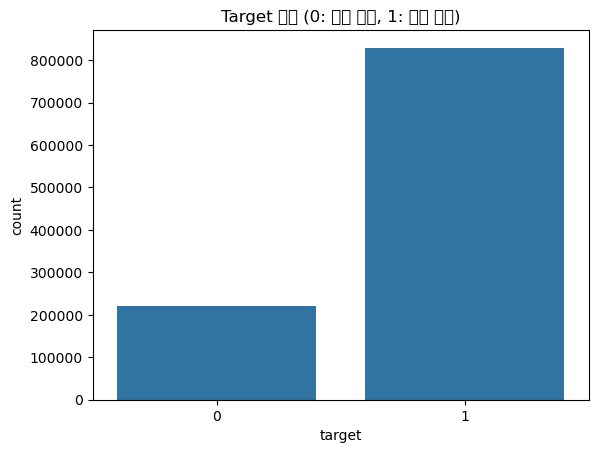

In [17]:
# 1. 구조 확인
df_main[select_cols].info()

# 2. 수치형 통계 요약
df_main[select_cols].describe()

# 3. 타겟 분포 시각화
sns.countplot(x='target', data=df_main)
plt.title('Target 분포 (0: 상환 실패, 1: 상환 완료)')
plt.show()

## Target 분포 확인

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\1884573943.py:19: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from current font.
  plt.tight_layout()
C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\1884573943.py:19: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from current font.
  plt.tight_layout()
C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\1884573943.py:19: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from current font.
  plt.tight_layout()
C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\1884573943.py:19: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from current font.
  plt.tight_layout()
C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\1884573943.py:19: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from current font.
  plt.

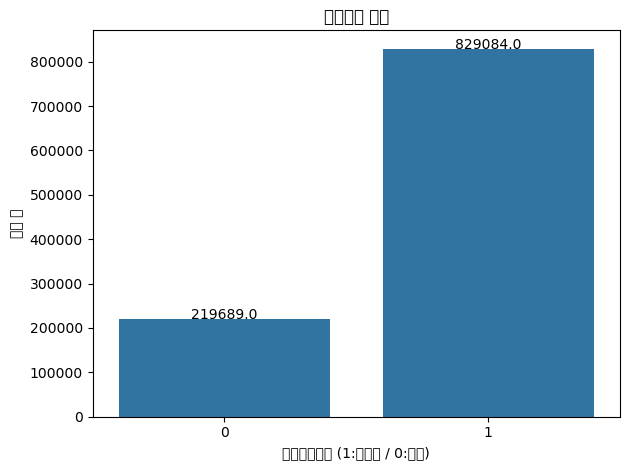

In [18]:
#1.target(대출상환 여부) 분포 count
target_counts = df_filtered['target'].value_counts()
target_counts

#target분포 비율
df_filtered['target'].value_counts(normalize=True)

ax = sns.countplot(x='target', data=df_main2)
plt.title('대출상환 분포')
plt.xlabel('대출상환여부 (1:미상환 / 0:상환)')
plt.ylabel('고객 수')

# 막대 위에 숫자 표시
for p in ax.patches:
    
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.1, f'{height}', ha='center')

plt.tight_layout()
plt.show()

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\1237417329.py:12: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from current font.
  plt.tight_layout()
C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\1237417329.py:12: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from current font.
  plt.tight_layout()
C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\1237417329.py:12: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from current font.
  plt.tight_layout()
C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\1237417329.py:12: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from current font.
  plt.tight_layout()
C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\1237417329.py:12: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from current font.
  plt.

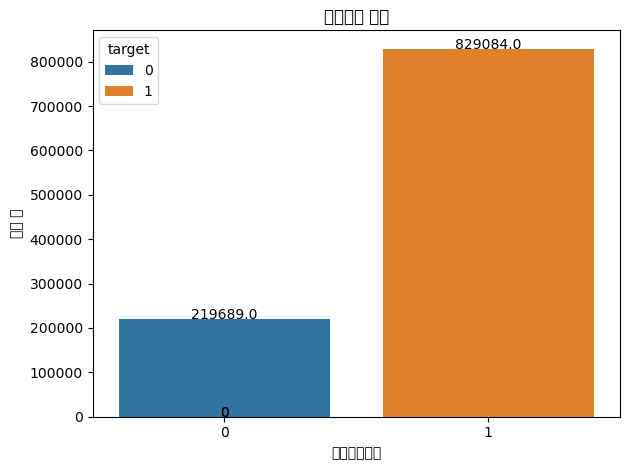

In [19]:
ax = sns.countplot(x='target', data=df_main2,hue='target')
plt.title('대출상환 분포')
plt.xlabel('대출상환여부')
plt.ylabel('고객 수')

# 막대 위에 숫자 표시
for p in ax.patches:
    
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 0.1, f'{height}', ha='center')

plt.tight_layout()
plt.show()

## loan_amnt, int_rate, dti, fico_mean 분포(boxplot)

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

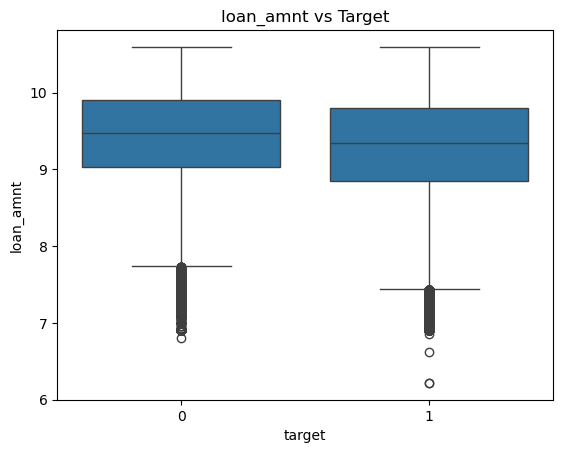

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

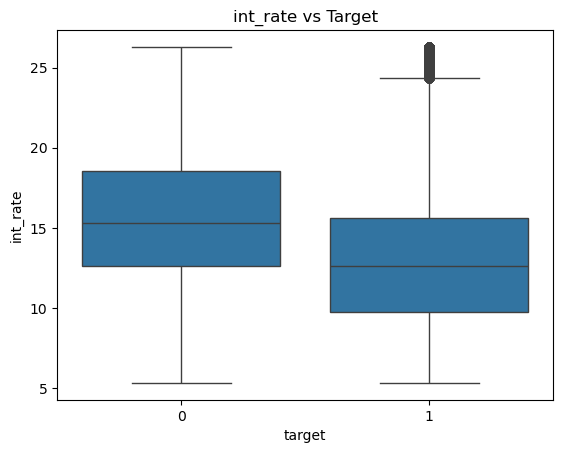

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

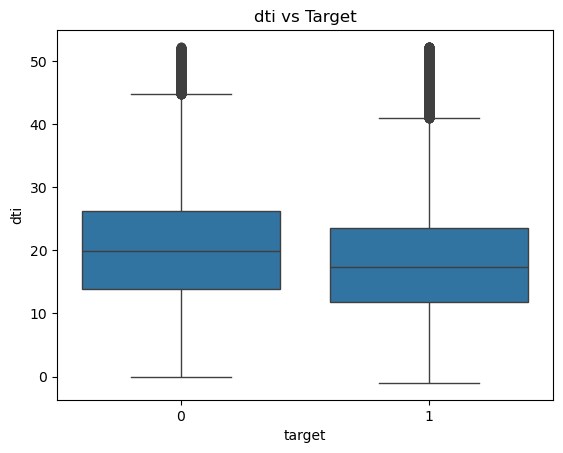

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

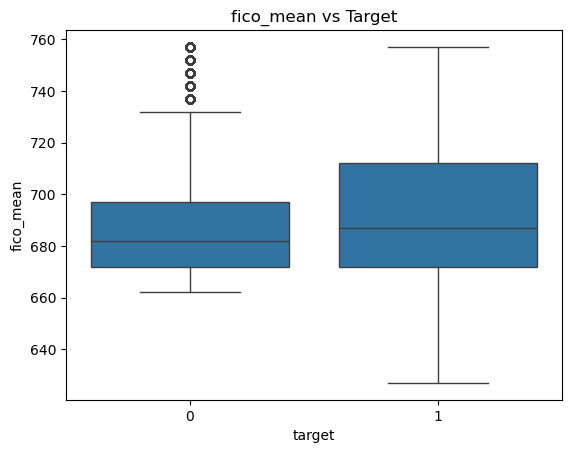

In [20]:
for col in ['loan_amnt', 'int_rate', 'dti', 'fico_mean']:
    sns.boxplot(x='target', y=col, data=df_main)
    plt.title(f"{col} vs Target")
    plt.show()

## int_rate, fico_mean, loan_amnt, dti, revol_util 컬럼 pairplot

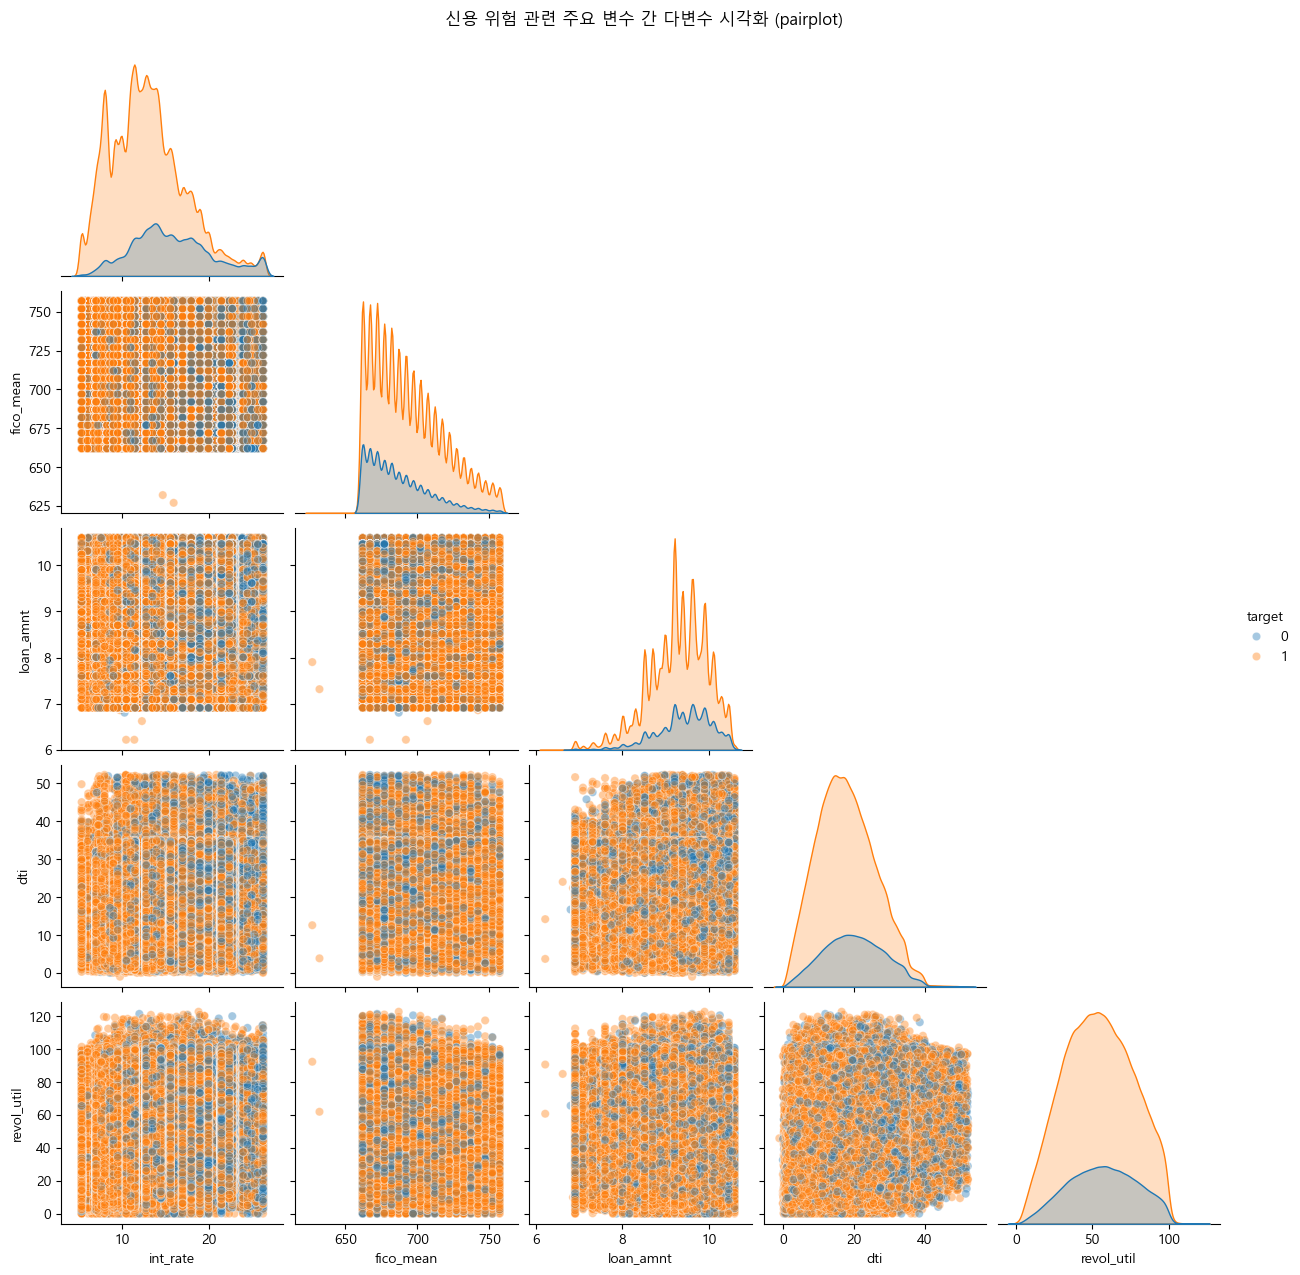

In [21]:
#sns.set(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 깨짐 방지

# 직접적인 영향을 줄 가능성이 높은 수치형 변수 선택
selected_features = ['int_rate', 'fico_mean', 'loan_amnt', 'dti', 'revol_util']

# pairplot 시각화 (target에 따라 hue 설정)
sns.pairplot(df_main2[selected_features + ['target']], hue='target', corner=True, plot_kws={'alpha': 0.4})
plt.suptitle("신용 위험 관련 주요 변수 간 다변수 시각화 (pairplot)", y=1.02)
plt.show()

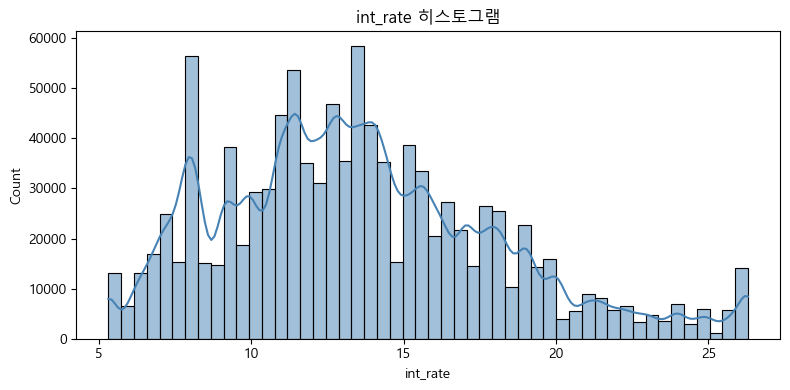

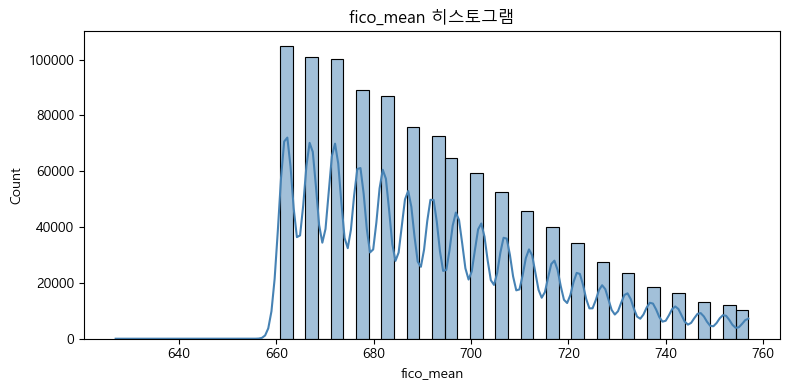

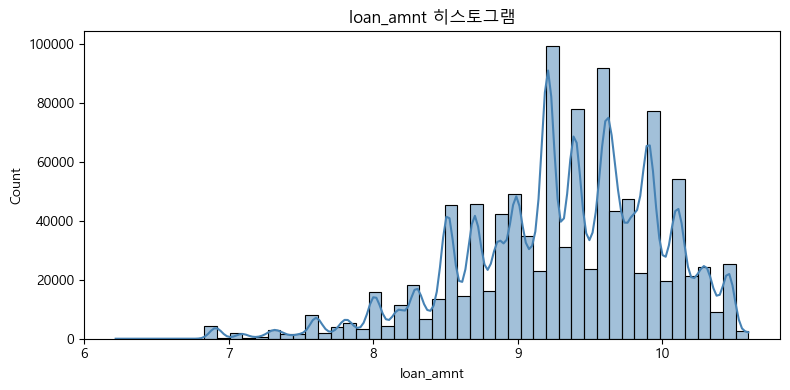

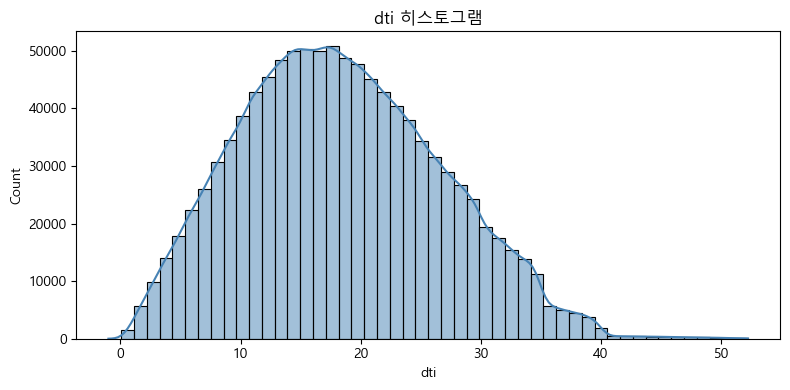

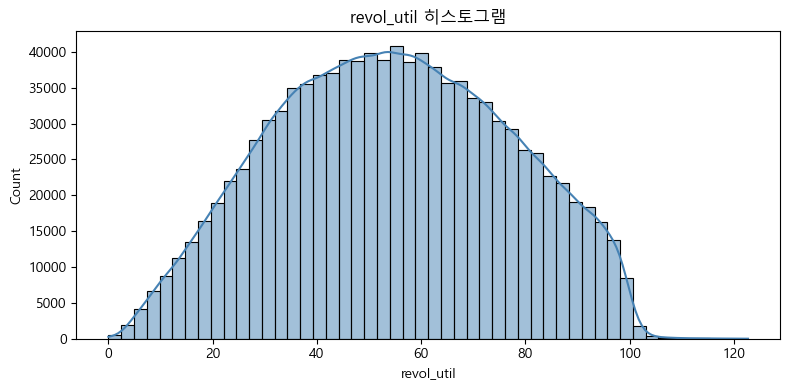

In [22]:
numeric_cols = ['int_rate', 'fico_mean', 'loan_amnt', 'dti', 'revol_util']

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df_main, x=col, bins=50, kde=True, color='steelblue')
    plt.title(f"{col} 히스토그램")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

## int_rate, fico_mean, loan_amnt, dti, revol_util의 target 분포

C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\2340255555.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df_main, palette=['#FF9999','#99CCFF'])


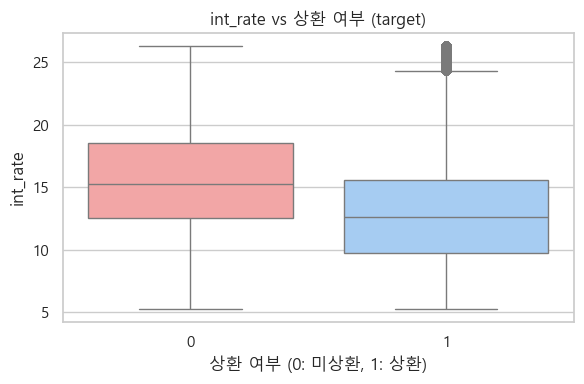

C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\2340255555.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df_main, palette=['#FF9999','#99CCFF'])


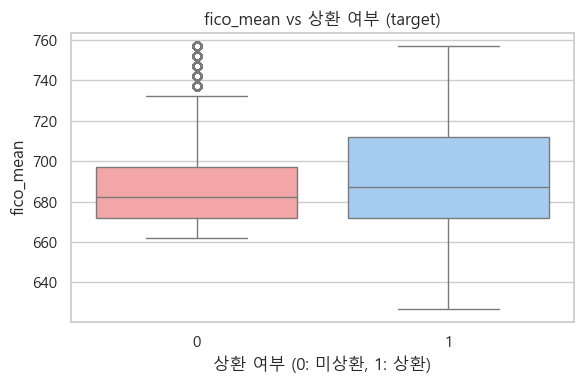

C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\2340255555.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df_main, palette=['#FF9999','#99CCFF'])


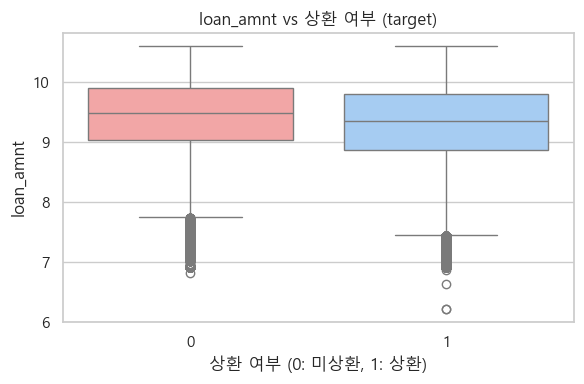

C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\2340255555.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df_main, palette=['#FF9999','#99CCFF'])


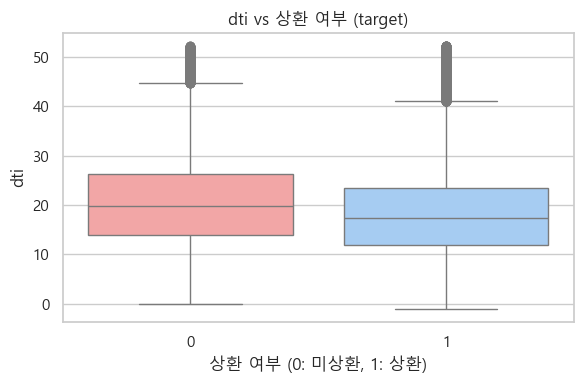

C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\2340255555.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y=col, data=df_main, palette=['#FF9999','#99CCFF'])


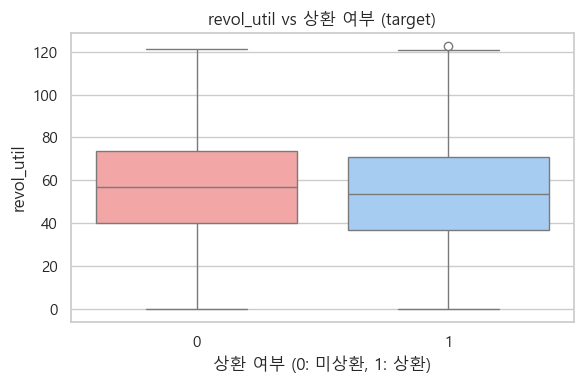

In [23]:
# 분석할 변수 리스트
numeric_cols = ['int_rate', 'fico_mean', 'loan_amnt', 'dti', 'revol_util']

# 시각화 설정
sns.set(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트 설정

# 각 변수별로 target에 따른 분포 비교(Boxplot)
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='target', y=col, data=df_main, palette=['#FF9999','#99CCFF'])
    plt.title(f"{col} vs 상환 여부 (target)")
    plt.xlabel("상환 여부 (0: 미상환, 1: 상환)")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

Text(0.5, 1.0, 'Clipped int_rate 히스토그램')

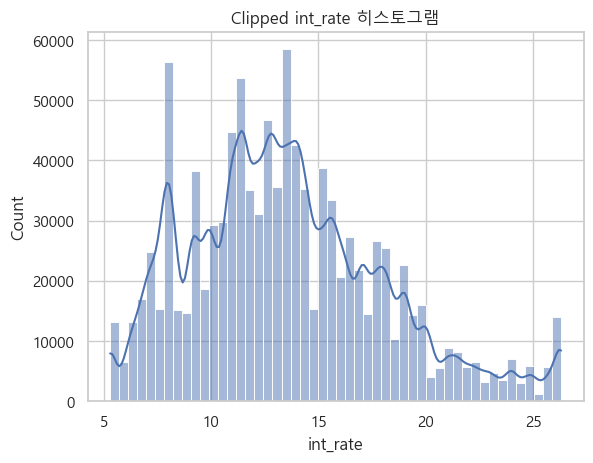

In [24]:
sns.histplot(df_main['int_rate'], bins=50, kde=True)
plt.title("Clipped int_rate 히스토그램")

In [25]:
df_original['loan_amnt'].describe()

count   2260668.00
mean      15046.93
std        9190.25
min         500.00
25%        8000.00
50%       12900.00
75%       20000.00
max       40000.00
Name: loan_amnt, dtype: float64

## purpose %비율로 확인

In [26]:
purpose_percent = df_original['purpose'].value_counts(normalize=True) * 100

# DataFrame으로 정리
df_purpose_dist = purpose_percent.reset_index()
df_purpose_dist.columns = ['purpose', 'percent']
df_purpose_dist

,purpose,percent
0,debt_consolidation,56.53
1,credit_card,22.87
2,home_improvement,6.66
3,other,6.17
4,major_purchase,2.23
5,medical,1.22
6,small_business,1.09
7,car,1.06
8,vacation,0.69
9,moving,0.68


## purpose 변수 상위5개 + other 그룹화해서 비교

In [27]:
top5 = df_filtered['purpose'].value_counts().index[:5].tolist()

# 2) purpose_grouped 시리즈 생성 (나머지는 'rest')
purpose_grouped = df_filtered['purpose'].where(
    df_filtered['purpose'].isin(top5),
    other='rest'
)

# 3) grouped_percent 계산 (%)
grouped_percent = purpose_grouped.value_counts(normalize=True) * 100

# 4) df_grouped 생성
df_grouped = grouped_percent.reset_index()
df_grouped.columns = ['purpose_grouped', 'percent']

C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\1419251529.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


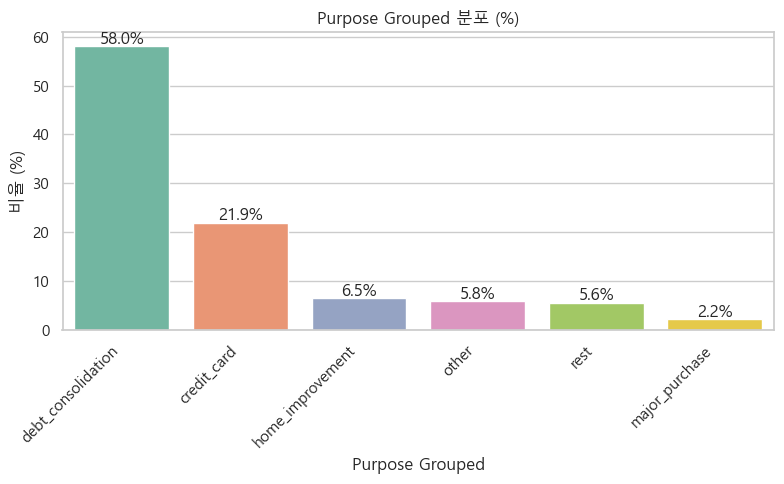

In [28]:
# 시각화: Bar plot
plt.figure(figsize=(8, 5))
sns.barplot(
    x='purpose_grouped', 
    y='percent', 
    data=df_grouped, 
    palette='Set2',
    order=df_grouped.sort_values('percent', ascending=False)['purpose_grouped']
)
plt.title("Purpose Grouped 분포 (%)")
plt.xlabel("Purpose Grouped")
plt.ylabel("비율 (%)")
plt.xticks(rotation=45, ha='right')

# 각 바 위에 퍼센트 값 표시
for idx, row in df_grouped.iterrows():
    plt.text(
        x=idx, 
        y=row['percent'] + 0.5, 
        s=f"{row['percent']:.1f}%", 
        ha='center'
    )

plt.tight_layout()
plt.show()

## purpose 카테고리 별 상환률

      purpose_grouped  success_rate
0  debt_consolidation         78.85
1         credit_card         83.07
2    home_improvement         82.28
3               other         78.96
4      major_purchase         81.39
5                rest         78.36


C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\457697594.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


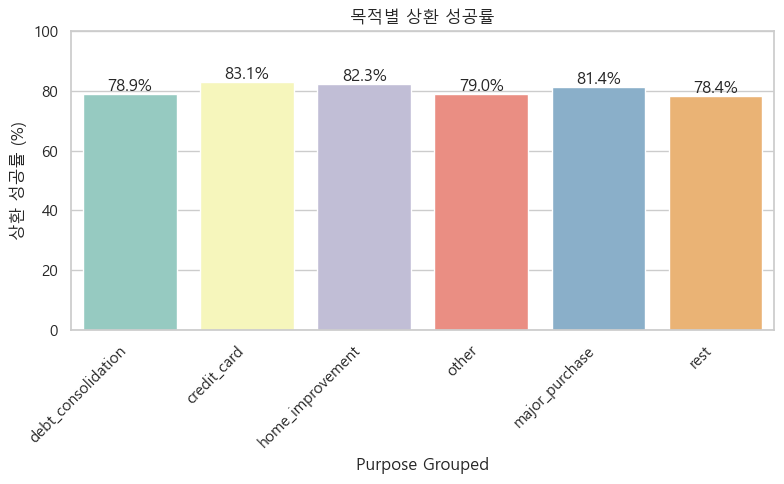

In [29]:
top5 = df_filtered['purpose'].value_counts().index[:5].tolist()

# ── 2) purpose_grouped 변수(원본 건드리지 않음) ─────────────────
purpose_grouped = df_filtered['purpose'].where(df_filtered['purpose'].isin(top5), other='rest')

# ── 3) 상환 성공률 계산 & reindex ───────────────────────────────
success_rate = ( 
    df_filtered.assign(purpose_grouped=purpose_grouped)
      .groupby('purpose_grouped')['target']
      .mean()
      * 100
)
# 원하는 순서: 상위5 + rest
order = top5 + ['rest']
success_rate = success_rate.reindex(order)

# ── 4) DataFrame 정리 ─────────────────────────────────────────
df_success = success_rate.reset_index()
df_success.columns = ['purpose_grouped', 'success_rate']

# ── 5) 결과 테이블 확인 ───────────────────────────────────────
print(df_success)

# ── 6) 막대그래프 그리기 ───────────────────────────────────────
plt.figure(figsize=(8,5))
sns.barplot(
    x='purpose_grouped',
    y='success_rate',
    data=df_success,
    order=order,
    palette='Set3'
)
plt.title("목적별 상환 성공률")
plt.xlabel("Purpose Grouped")
plt.ylabel("상환 성공률 (%)")
plt.ylim(0,100)
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(df_success['success_rate']):
    plt.text(i, v+1, f"{v:.1f}%", ha='center')
plt.tight_layout()
plt.show()

## fico_mean, delinq_2yrs, pub_rec, target간의 상관분석

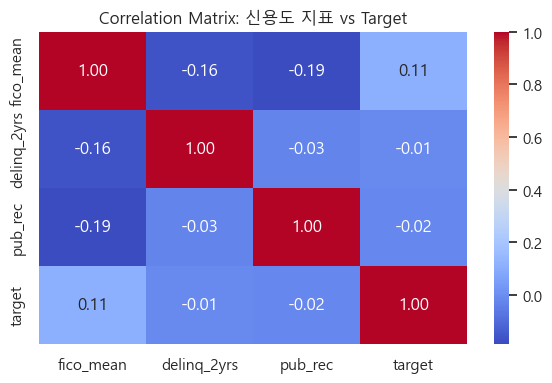

C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\2418354823.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='fico_mean', data=df_main, palette='Set2')


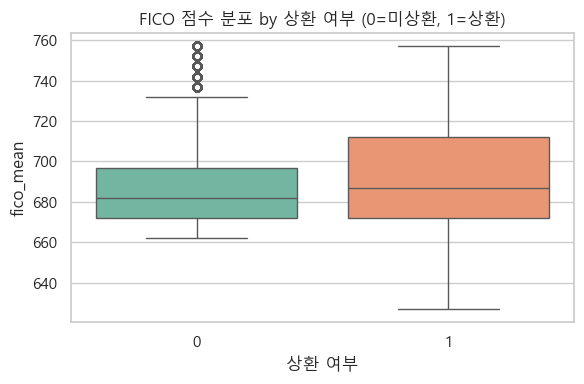

KeyError: 'credit_grade'

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# 1) 변수 선택
vars_corr = ['fico_mean', 'delinq_2yrs', 'pub_rec', 'target']

# 2) 상관계수 히트맵
plt.figure(figsize=(6, 4))
corr = df_main2[vars_corr].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: 신용도 지표 vs Target')
plt.tight_layout()
plt.show()

# 3) 박스플롯: FICO 점수 분포 비교
plt.figure(figsize=(6, 4))
sns.boxplot(x='target', y='fico_mean', data=df_main, palette='Set2')
plt.title('FICO 점수 분포 by 상환 여부 (0=미상환, 1=상환)')
plt.xlabel('상환 여부')
plt.ylabel('fico_mean')
plt.tight_layout()
plt.show()

# 4) 등급별 Default Rate (credit_grade)
grade_dr = df_main.groupby('credit_grade')['target'] \
                  .apply(lambda x: (x==0).mean() * 100) \
                  .sort_index()
plt.figure(figsize=(6, 4))
sns.barplot(x=grade_dr.index, y=grade_dr.values, palette='viridis')
plt.title('Credit Grade별 Default Rate (%)')
plt.ylabel('Default Rate (%)')
plt.xlabel('Credit Grade')
plt.tight_layout()
plt.show()

# 5) Delinq_2yrs 그룹별 Default Rate
df_main['delinq_bin'] = pd.cut(df_main['delinq_2yrs'],
                               bins=[-0.1, 0, 1, 2, df_main['delinq_2yrs'].max()],
                               labels=['0', '1', '2', '3+'])
delinq_dr = df_main.groupby('delinq_bin')['target'] \
                   .apply(lambda x: (x==0).mean() * 100)
plt.figure(figsize=(6, 4))
sns.barplot(x=delinq_dr.index, y=delinq_dr.values, palette='magma')
plt.title('Delinq_2yrs별 Default Rate (%)')
plt.xlabel('Delinq_2yrs')
plt.ylabel('Default Rate (%)')
plt.tight_layout()
plt.show()

# 6) Pub_Rec 그룹별 Default Rate
df_main['pubrec_bin'] = pd.cut(df_main['pub_rec'],
                               bins=[-0.1, 0, 1, 2, df_main['pub_rec'].max()],
                               labels=['0', '1', '2', '3+'])
pubrec_dr = df_main.groupby('pubrec_bin')['target'] \
                   .apply(lambda x: (x==0).mean() * 100)
plt.figure(figsize=(6, 4))
sns.barplot(x=pubrec_dr.index, y=pubrec_dr.values, palette='coolwarm')
plt.title('Pub_Rec별 Default Rate (%)')
plt.xlabel('Pub_Rec')
plt.ylabel('Default Rate (%)')
plt.tight_layout()
plt.show()


## fico_mean, delinq_2yrs, target 샘플링 후 상환 분포 확인

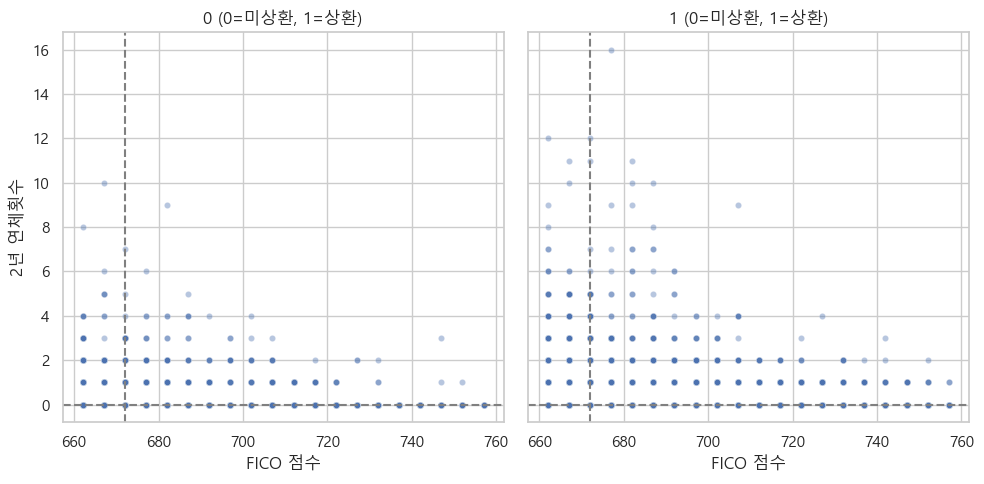

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1) 샘플링
df = df_main[['fico_mean','delinq_2yrs','target']].sample(10000, random_state=42)

# 2) FacetGrid 생성
g = sns.FacetGrid(df, col="target", height=5, sharex=True, sharey=True,
                  col_order=[0,1], despine=False)
g.map(sns.scatterplot, "fico_mean", "delinq_2yrs", s=20, alpha=0.4)
g.set_axis_labels("FICO 점수", "2년 연체횟수")
g.set_titles("{col_name} (0=미상환, 1=상환)")

# 3) 기준선 추가
for ax in g.axes.flat:
    ax.axvline(df['fico_mean'].quantile(0.25), ls='--', color='gray')
    ax.axhline(df['delinq_2yrs'].quantile(0.75), ls='--', color='gray')

plt.tight_layout()
plt.show()



## fico_mean, delinq_2yrs 상환여부 등고선

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


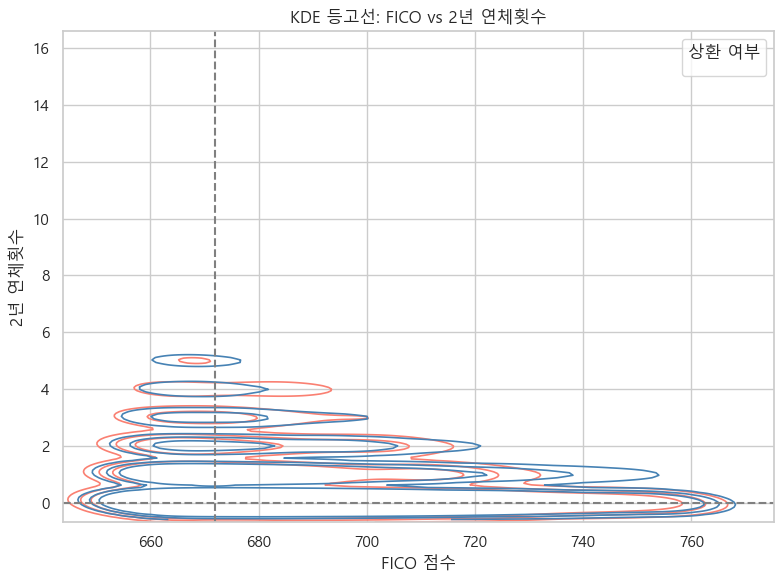

In [32]:
plt.figure(figsize=(8,6))

# 0=미상환, 1=상환 각각 KDE 경계선
sns.kdeplot(df[df.target==0], x="fico_mean", y="delinq_2yrs",
            levels=[0.02,0.05,0.1], color="salmon", label="미상환", linewidths=1.2)
sns.kdeplot(df[df.target==1], x="fico_mean", y="delinq_2yrs",
            levels=[0.02,0.05,0.1], color="steelblue", label="상환", linewidths=1.2)

# 기준선
plt.axvline(df['fico_mean'].quantile(0.25), ls='--', color='gray')
plt.axhline(df['delinq_2yrs'].quantile(0.75), ls='--', color='gray')

plt.legend(title="상환 여부")
plt.title("KDE 등고선: FICO vs 2년 연체횟수")
plt.xlabel("FICO 점수")
plt.ylabel("2년 연체횟수")
plt.tight_layout()
plt.show()


## fico_mean, pub_rec과 target간의 상관계수

C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\4154628456.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['fico_bin']   = pd.cut(df['fico_mean'], bins=10)
C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\4154628456.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pubrec_bin'] = pd.cut(df['pub_rec'],


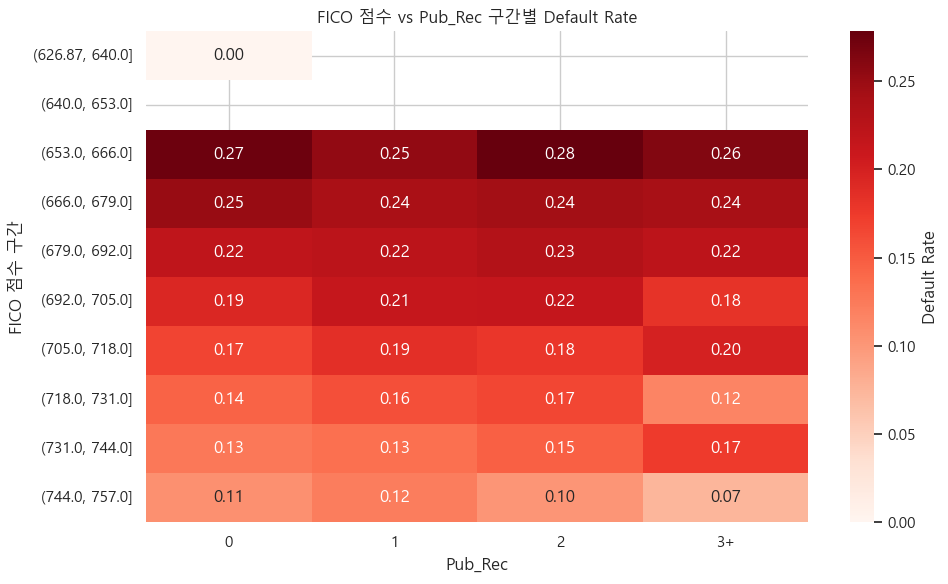

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 0) 데이터 로드 — 실제 경로로 수정하세요.
# df_main = pd.read_csv('/mnt/data/df_main_selected_columns.csv')

# 1) 관심 컬럼만 샘플링
df = df_main2[['fico_mean','pub_rec','target']]

# 2) FICO는 10구간, Pub_Rec는 원래 값(0,1,2,3+) 그대로
df['fico_bin']   = pd.cut(df['fico_mean'], bins=10)
df['pubrec_bin'] = pd.cut(df['pub_rec'],
                          bins=[-0.1,0,1,2,df['pub_rec'].max()],
                          labels=['0','1','2','3+'])

# 3) Pivot table로 구간별 default rate 계산
#    (target==0 이 default)
pivot = df.groupby(['fico_bin','pubrec_bin'])['target'] \
          .apply(lambda x: (x==0).mean()) \
          .unstack()

# 4) 히트맵 시각화
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='Reds',
            cbar_kws={'label':'Default Rate'})
plt.title("FICO 점수 vs Pub_Rec 구간별 Default Rate")
plt.xlabel("Pub_Rec")
plt.ylabel("FICO 점수 구간")
plt.yticks(rotation=0)    # Y축 라벨 수평 정렬
plt.tight_layout()
plt.show()


## fico_mean 신용점수 범위

C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\1439161877.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='fico_mean', data=df_main2, palette=['#FF6B6B', '#4ECDC4'])


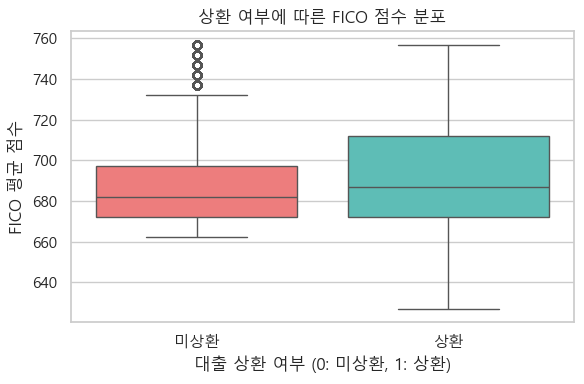

In [34]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='target', y='fico_mean', data=df_main2, palette=['#FF6B6B', '#4ECDC4'])
plt.title('상환 여부에 따른 FICO 점수 분포')
plt.xlabel('대출 상환 여부 (0: 미상환, 1: 상환)')
plt.ylabel('FICO 평균 점수')
plt.xticks([0, 1], ['미상환', '상환'])
plt.tight_layout()
plt.show()

## open_acc(개설된 신용 계좌 수) 분포 및 상환여부

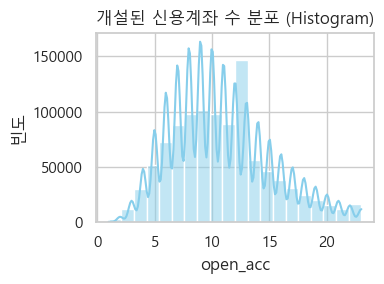

C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\1045988826.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='open_acc', data=df_main2, palette=['lightcoral', 'skyblue'])


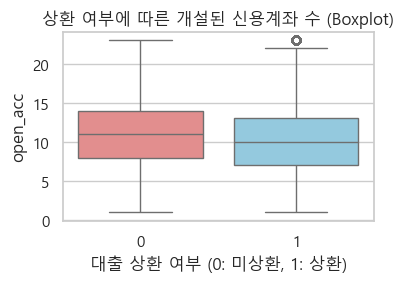

In [35]:
plt.figure(figsize=(4, 3))
sns.histplot(data=df_main2, x='open_acc', bins=20, kde=True, color='skyblue')
plt.title('개설된 신용계좌 수 분포 (Histogram)')
plt.xlabel('open_acc')
plt.ylabel('빈도')
plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 3))
sns.boxplot(x='target', y='open_acc', data=df_main2, palette=['lightcoral', 'skyblue'])
plt.title('상환 여부에 따른 개설된 신용계좌 수 (Boxplot)')
plt.xlabel('대출 상환 여부 (0: 미상환, 1: 상환)')
plt.ylabel('open_acc')
plt.tight_layout()
plt.show()

## total_acc(전체 계좌 수) 상환여부

C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\4158710151.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='total_acc', data=df_main2, palette=['lightcoral', 'skyblue'])


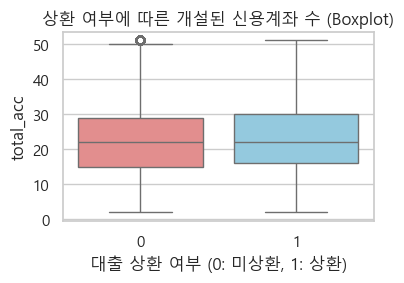

In [36]:
plt.figure(figsize=(4, 3))
sns.boxplot(x='target', y='total_acc', data=df_main2, palette=['lightcoral', 'skyblue'])
plt.title('상환 여부에 따른 개설된 신용계좌 수 (Boxplot)')
plt.xlabel('대출 상환 여부 (0: 미상환, 1: 상환)')
plt.ylabel('total_acc')
plt.tight_layout()
plt.show()

## pub_rec(파산 횟수) 상환여부

C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\2878653666.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_main2, x='target', y='pub_rec', palette=['lightcoral', 'skyblue'])


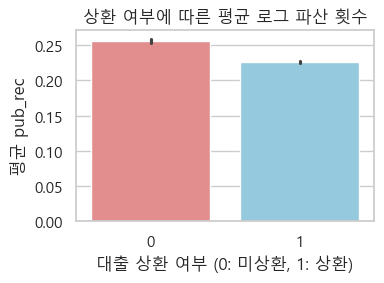

In [37]:
plt.figure(figsize=(4, 3))
sns.barplot(data=df_main2, x='target', y='pub_rec', palette=['lightcoral', 'skyblue'])
plt.title('상환 여부에 따른 평균 로그 파산 횟수')
plt.xlabel('대출 상환 여부 (0: 미상환, 1: 상환)')
plt.ylabel('평균 pub_rec')
plt.tight_layout()
plt.show()

## delinq_2yrs(최근 2년 연체 횟수) 상환여부

C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\3289858395.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_main2, x='target', y='delinq_2yrs', palette=['lightcoral', 'skyblue'])


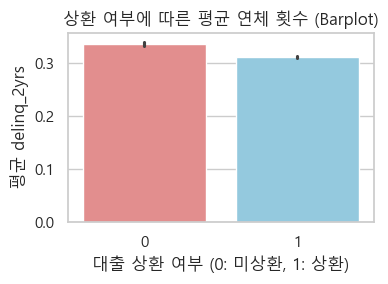

In [38]:
# Barplot: 상환 여부(target)에 따른 평균 연체 횟수
plt.figure(figsize=(4, 3))
sns.barplot(data=df_main2, x='target', y='delinq_2yrs', palette=['lightcoral', 'skyblue'])
plt.title('상환 여부에 따른 평균 연체 횟수 (Barplot)')
plt.xlabel('대출 상환 여부 (0: 미상환, 1: 상환)')
plt.ylabel('평균 delinq_2yrs')
plt.tight_layout()
plt.show()

## installment(월 상환금) 분포 및 상환여부

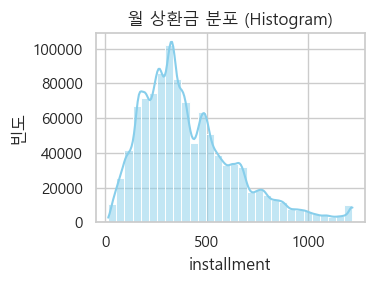

C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\619984606.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='installment', data=df_main2, palette=['lightcoral', 'skyblue'])


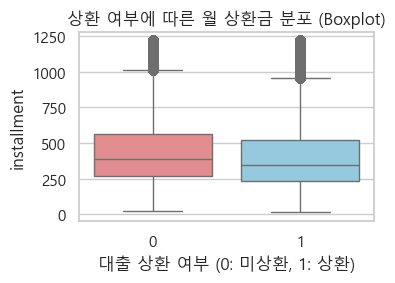

In [39]:
# 히스토그램
plt.figure(figsize=(4, 3))
sns.histplot(data=df_main2, x='installment', bins=30, kde=True, color='skyblue')
plt.title('월 상환금 분포 (Histogram)')
plt.xlabel('installment')
plt.ylabel('빈도')
plt.tight_layout()
plt.show()

# 박스플롯
plt.figure(figsize=(4, 3))
sns.boxplot(x='target', y='installment', data=df_main2, palette=['lightcoral', 'skyblue'])
plt.title('상환 여부에 따른 월 상환금 분포 (Boxplot)')
plt.xlabel('대출 상환 여부 (0: 미상환, 1: 상환)')
plt.ylabel('installment')
plt.tight_layout()
plt.show()

## emp_length(고용 기간) 분포 및 상환여부 !!!!

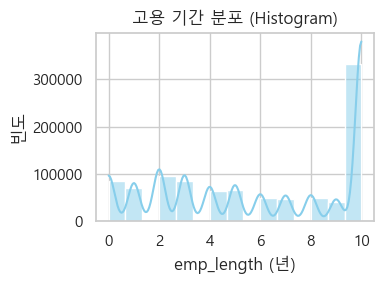

C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\1862874071.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='emp_length', data=df_main2, palette=['lightcoral', 'skyblue'])


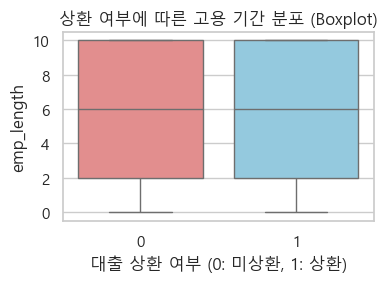

In [40]:
# 히스토그램
plt.figure(figsize=(4, 3))
sns.histplot(data=df_main2, x='emp_length', bins=15, kde=True, color='skyblue')
plt.title('고용 기간 분포 (Histogram)')
plt.xlabel('emp_length (년)')
plt.ylabel('빈도')
plt.tight_layout()
plt.show()

# 박스플롯
plt.figure(figsize=(4, 3))
sns.boxplot(x='target', y='emp_length', data=df_main2, palette=['lightcoral', 'skyblue'])
plt.title('상환 여부에 따른 고용 기간 분포 (Boxplot)')
plt.xlabel('대출 상환 여부 (0: 미상환, 1: 상환)')
plt.ylabel('emp_length')
plt.tight_layout()
plt.show()

## annual_inc(연간 소득) 분포 및 상환여부

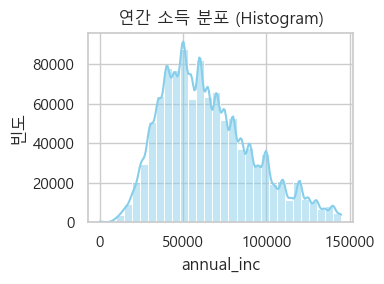

C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\3078635050.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='annual_inc', data=df_main2, palette=['lightcoral', 'skyblue'])


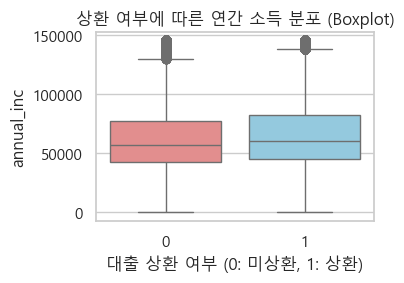

In [41]:
# 히스토그램
plt.figure(figsize=(4, 3))
sns.histplot(data=df_main2, x='annual_inc', bins=30, kde=True, color='skyblue')
plt.title('연간 소득 분포 (Histogram)')
plt.xlabel('annual_inc')
plt.ylabel('빈도')
plt.tight_layout()
plt.show()

# 박스플롯
plt.figure(figsize=(4, 3))
sns.boxplot(x='target', y='annual_inc', data=df_main2, palette=['lightcoral', 'skyblue'])
plt.title('상환 여부에 따른 연간 소득 분포 (Boxplot)')
plt.xlabel('대출 상환 여부 (0: 미상환, 1: 상환)')
plt.ylabel('annual_inc')
plt.tight_layout()
plt.show()


## sub_grade와 target에 따른 분포(stakced bar plot)

<Figure size 1400x700 with 0 Axes>

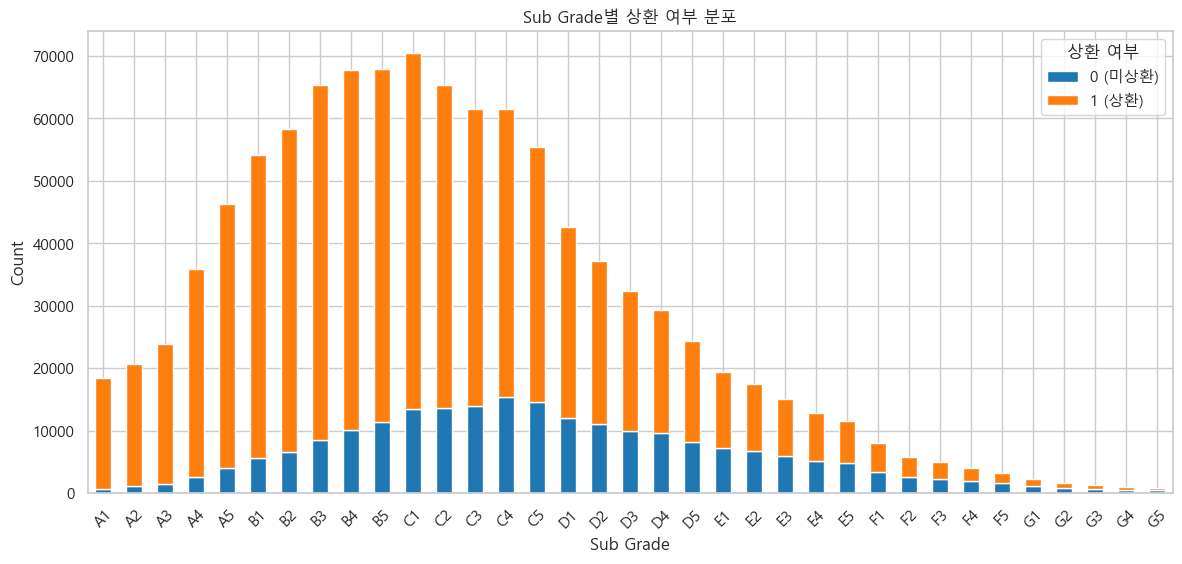

In [42]:
# sub_grade와 target에 따른 분포를 보여주는 stacked bar plot
plt.figure(figsize=(14, 7))
df_subgrade_target = df_main2.groupby(['sub_grade', 'target']).size().unstack()

# Stack Bar Plot
df_subgrade_target.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'], figsize=(14, 6))
plt.title('Sub Grade별 상환 여부 분포')
plt.xlabel('Sub Grade')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='상환 여부', labels=['0 (미상환)', '1 (상환)'])
plt.show()

## subgrade의 대출상환률 분포

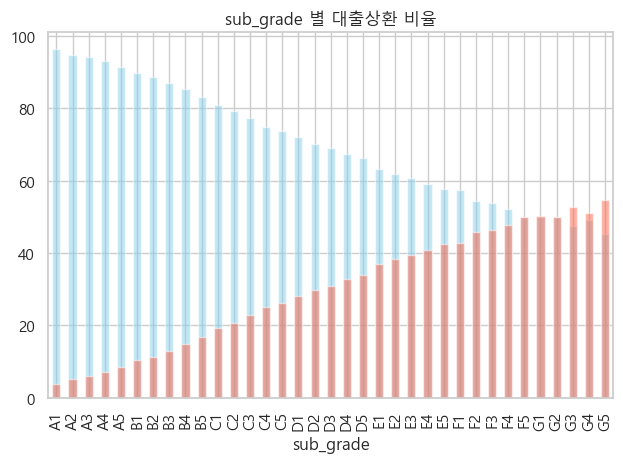

In [43]:
# 신용등급이 낮아질수록 미상환할 가능성이 높다
# pd.crosstab(행으로_쓸_컬럼, 열으로_쓸_컬럼, normalize='index' or 'columns'의 비율을 계산)
subgrade_ratio = pd.crosstab(df_main2['sub_grade'], df_main2['target'], normalize='index')*100

#시각화
subgrade_ratio[0].sort_index().plot(kind='bar', color = 'tomato', alpha=0.5, label='상환하지 않음(0)', zorder=2)
subgrade_ratio[1].sort_index().plot(kind='bar', color = 'skyblue', alpha=0.5, label='상환함(1)',zorder=1)
plt.title('sub_grade 별 대출상환 비율')
plt.tight_layout()
plt.show()

## home_ownership 도넛 차트(상환여부)

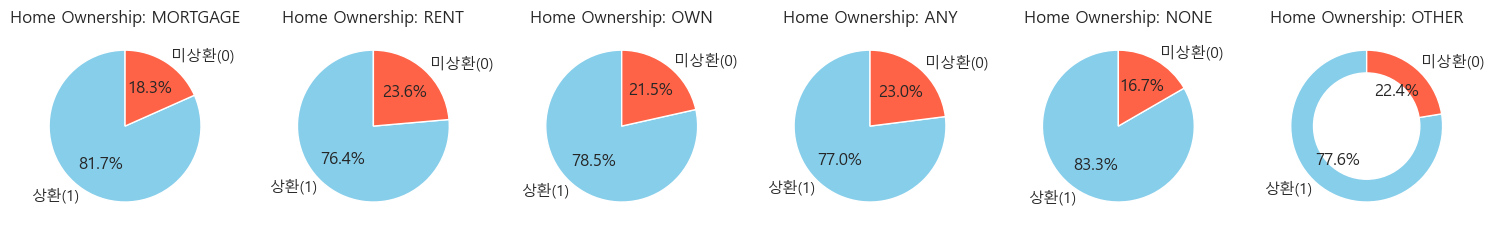

In [44]:
import matplotlib.pyplot as plt

# 전체 subplot 만들기
fig, axes = plt.subplots(1, len(df_main2['home_ownership'].unique()), figsize=(15, 5))

# home_ownership별로 도넛 차트 그리기
for i, ho in enumerate(df_main2['home_ownership'].unique()):
    # 해당 주거 유형의 상환여부 비율 계산
    data = df_main2[df_main2
['home_ownership'] == ho]['target'].value_counts(normalize=True) * 100
    # 도넛 차트 그리기
    wedges, texts, autotexts = axes[i].pie(data, labels=['상환(1)', '미상환(0)'], autopct='%1.1f%%',
                                          startangle=90, colors=['skyblue', 'tomato'])
    # 도넛 모양으로 만들기
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)
    
    # 제목 설정
    axes[i].set_title(f'Home Ownership: {ho}')

# 제목 간격을 잘 조정하여 겹침 방지
plt.tight_layout()
plt.subplots_adjust(top=0.85)  # 이 부분으로 제목 간격을 조정

plt.show()

## home_ownership 분포

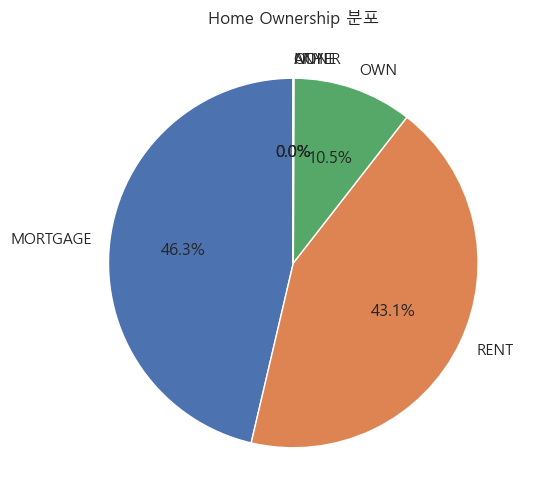

In [45]:
# Pie Chart: home_ownership 전체 분포
plt.figure(figsize=(6, 6))
df_main2['home_ownership'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, )
plt.title('Home Ownership 분포')
plt.ylabel('')  # y축 라벨 제거
plt.show()

## home_ownership 전체 비율

C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\3599601470.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_main2, x='home_ownership', palette='Set1')


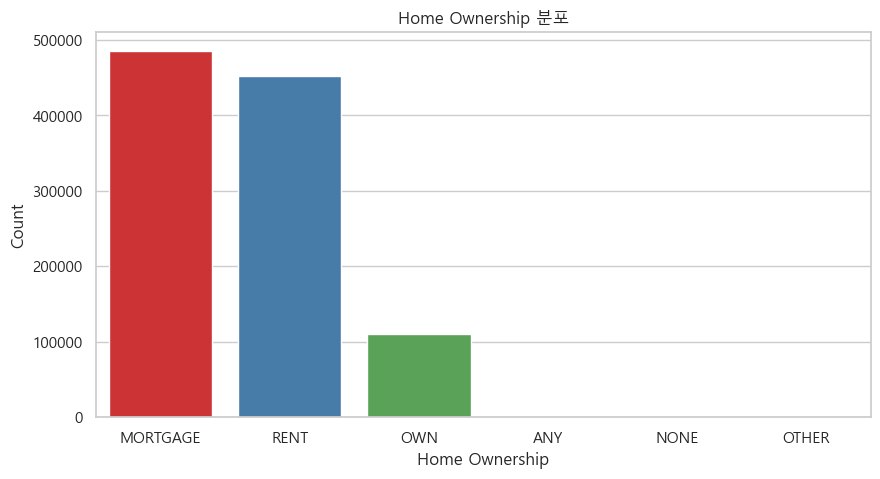

In [46]:
#home_ownership 전체 비율
df_main2['home_ownership'].value_counts()
df_main2['home_ownership'].value_counts(normalize=True)*100

plt.figure(figsize=(10,5))
sns.countplot(data=df_main2, x='home_ownership', palette='Set1')
plt.title('Home Ownership 분포')
plt.xlabel('Home Ownership')
plt.ylabel('Count')
plt.show()

## home_ownership 상환 여부에 따른 분포

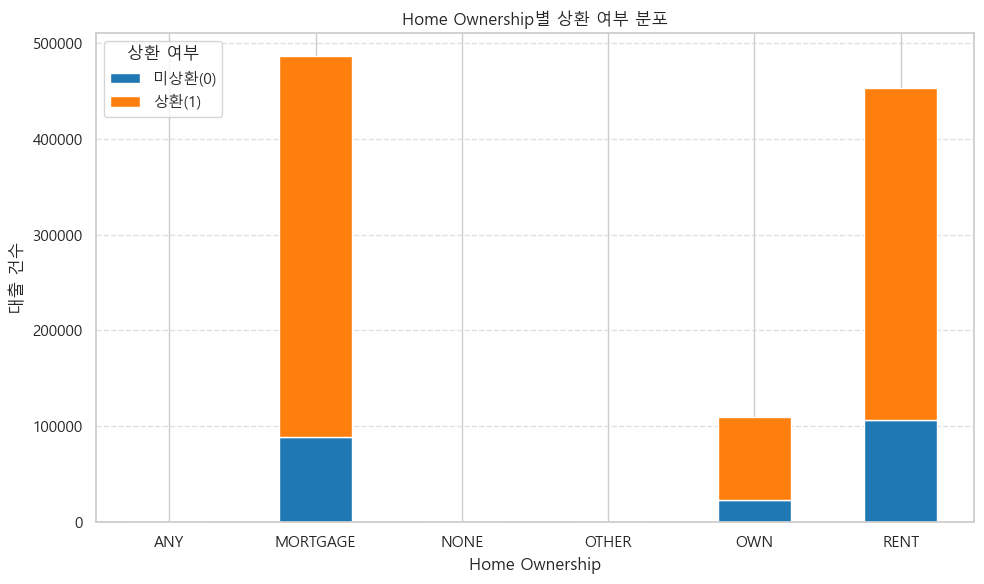

In [47]:
# groupby를 통해 target과 home_ownership에 따라 집계
df_ho_target = df_main2.groupby(['home_ownership', 'target']).size().unstack()

# 시각화
df_ho_target.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#1f77b4', '#ff7f0e'])
plt.title('Home Ownership별 상환 여부 분포')
plt.xlabel('Home Ownership')
plt.ylabel('대출 건수')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='상환 여부', labels=[ '미상환(0)','상환(1)',])
plt.tight_layout()
plt.show()

## verification_

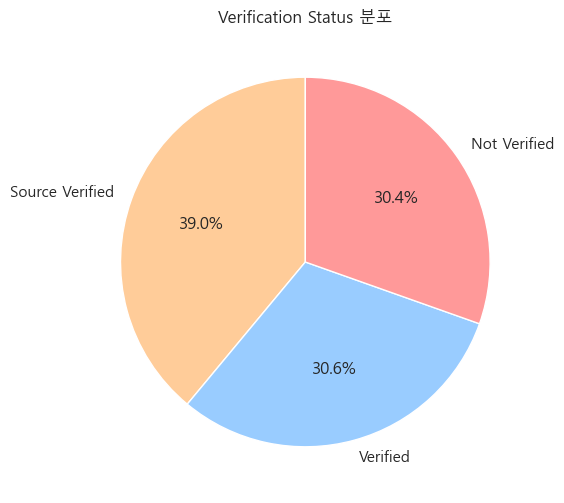

In [48]:
# 분포 파악 (파이 차트)
df_main2['verification_status'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', startangle=90, figsize=(6, 6),
    colors=['#ffcc99', '#99ccff', '#ff9999']
)
plt.title('Verification Status 분포')
plt.ylabel('')
plt.show()


## verification_status 대출상환 여부 분포

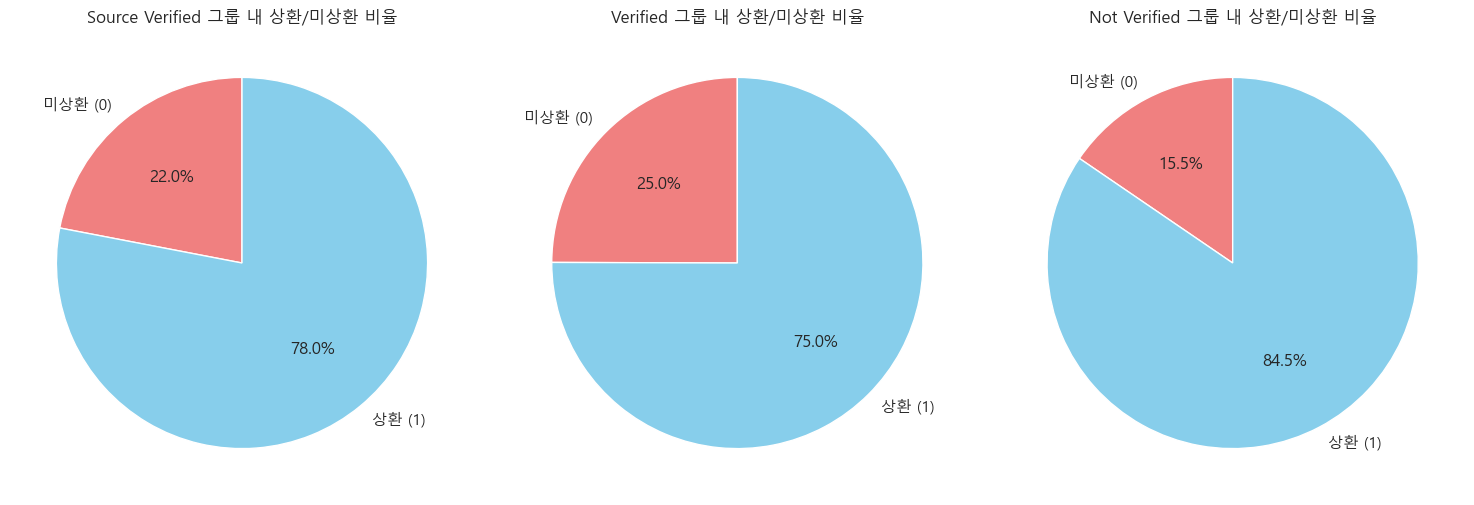

In [62]:
import matplotlib.pyplot as plt

# 1. verification_status별 target 비율 계산
grouped = df_main2.groupby('verification_status')['target'].value_counts(normalize=True).unstack()

# 2. 시각화
fig, axes = plt.subplots(1, 3, figsize=(15,5))

statuses = ['Source Verified', 'Verified', 'Not Verified']

for i, status in enumerate(statuses):
    ax = axes[i]
    sizes = grouped.loc[status]
    labels = ['미상환 (0)', '상환 (1)']
    colors = ['lightcoral', 'skyblue']
    ax.pie(
        sizes,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors
    )
    ax.set_title(f'{status} 그룹 내 상환/미상환 비율')

plt.tight_layout()
plt.show()


## purpose 분포

C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\3611106144.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_main2, x='purpose', palette='Set2')


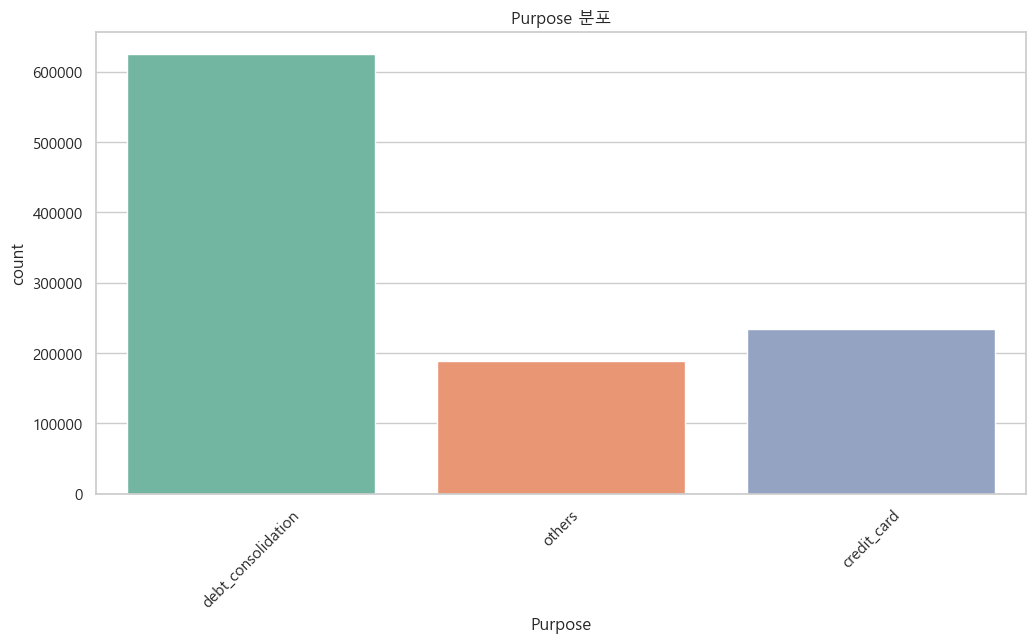

In [49]:
#분포
plt.figure(figsize=(12,6))
sns.countplot(data=df_main2, x='purpose', palette='Set2')
plt.title('Purpose 분포')
plt.xlabel('Purpose')
plt.ylabel('count')
plt.xticks(rotation=45)
plt.show()

## 대출 목적 별 상환률

C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\177570723.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=purpose_target_ct, x='purpose', y='상환률', palette='coolwarm')


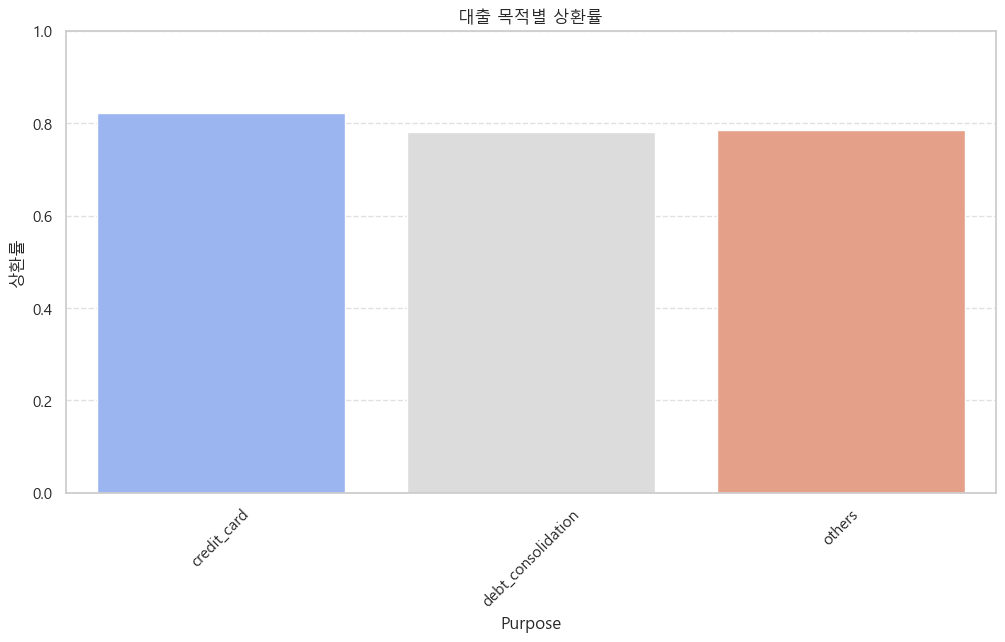

In [50]:
# 1. purpose별 상환률 계산
purpose_target_ct = df_main2.groupby('purpose')['target'].mean().reset_index()
purpose_target_ct.rename(columns={'target': '상환률'}, inplace=True)

# 2. 바플롯 그리기
plt.figure(figsize=(12,6))
sns.barplot(data=purpose_target_ct, x='purpose', y='상환률', palette='coolwarm')
plt.title('대출 목적별 상환률')
plt.xlabel('Purpose')
plt.ylabel('상환률')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()

## addr_state 지역별 분포

C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\2409002851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_main2, x='addr_state', palette='cubehelix')


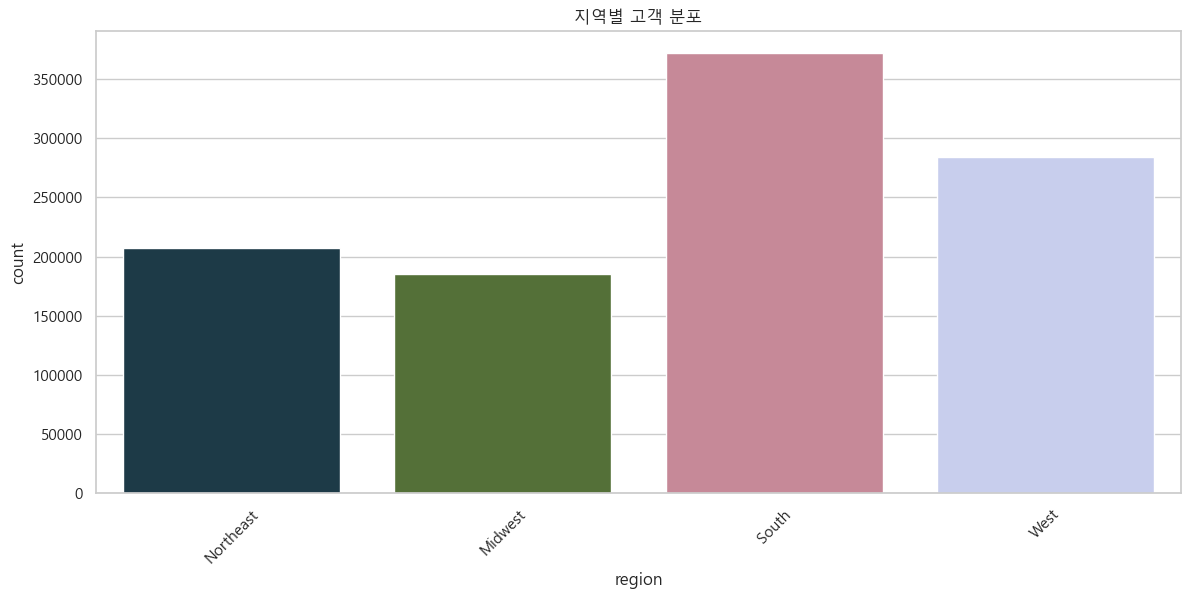

In [51]:
#지역별 고객 분포
plt.figure(figsize=(14,6))
sns.countplot(data=df_main2, x='addr_state', palette='cubehelix')
plt.title('지역별 고객 분포')
plt.xlabel('region')
plt.ylabel('count')
plt.xticks(rotation=45)
plt.show()

## addr_state 지역별 상환여부 분포

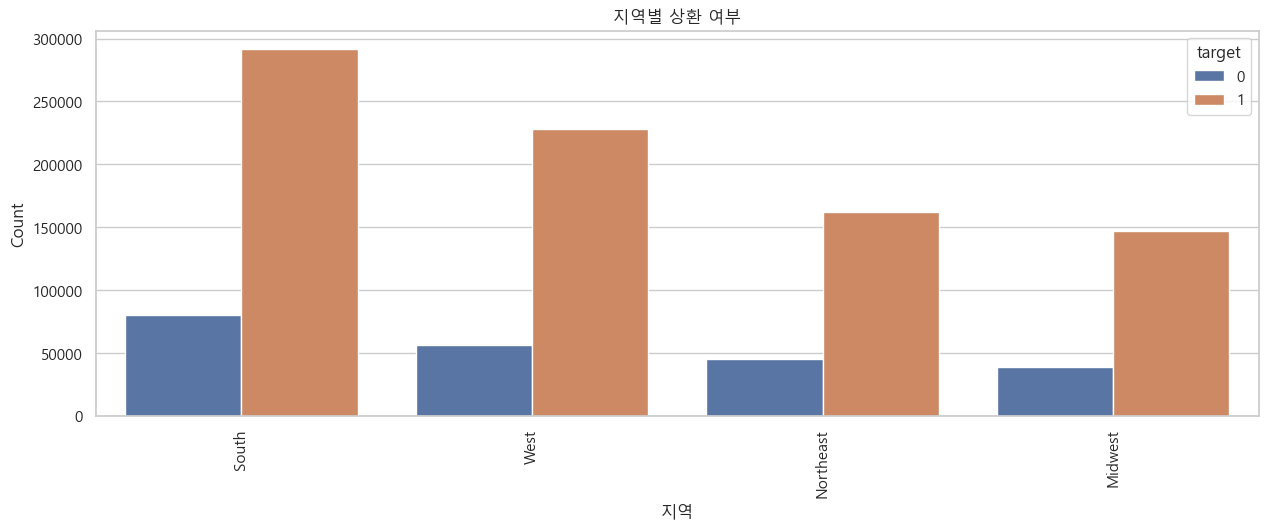

In [52]:
plt.figure(figsize=(15, 5))
sns.countplot(data=df_main2, x='addr_state', hue='target', order=df_main2['addr_state'].value_counts().index)
plt.title('지역별 상환 여부')
plt.xlabel('지역')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

## addr_state 지역별 상환 실패 비율

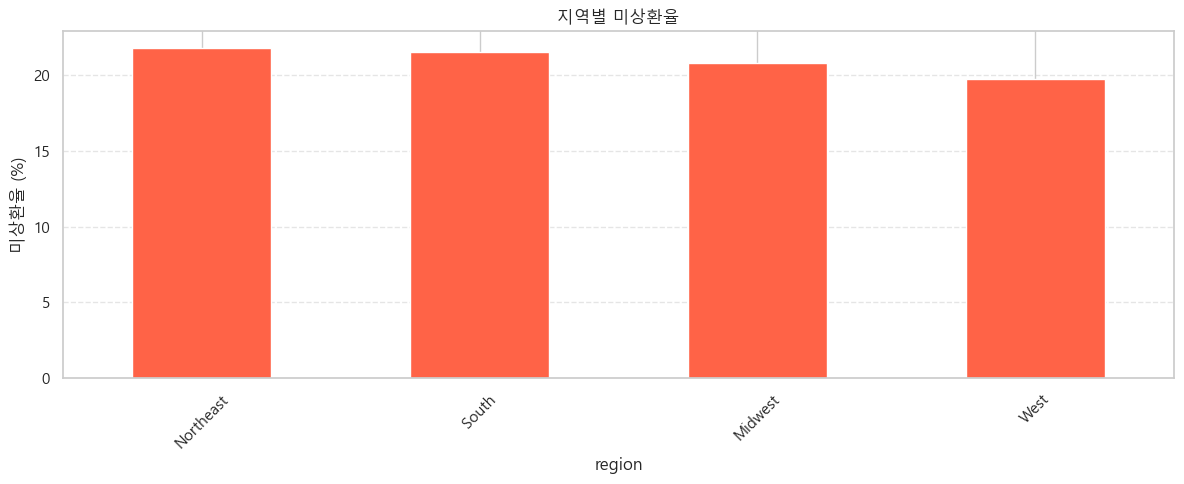

In [53]:
# 상환 여부 분포(비율)
addr = df_main2.groupby(['addr_state', 'target']).size().unstack()
addr_ratio = addr[0] / (addr[0] + addr[1]) * 100

# 시각화
addr_ratio.sort_values(ascending=False).plot(
    kind='bar', figsize=(12, 5), color='tomato'
)
plt.title('지역별 미상환율')
plt.ylabel('미상환율 (%)')
plt.xlabel('region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## application_type(신청 유형)

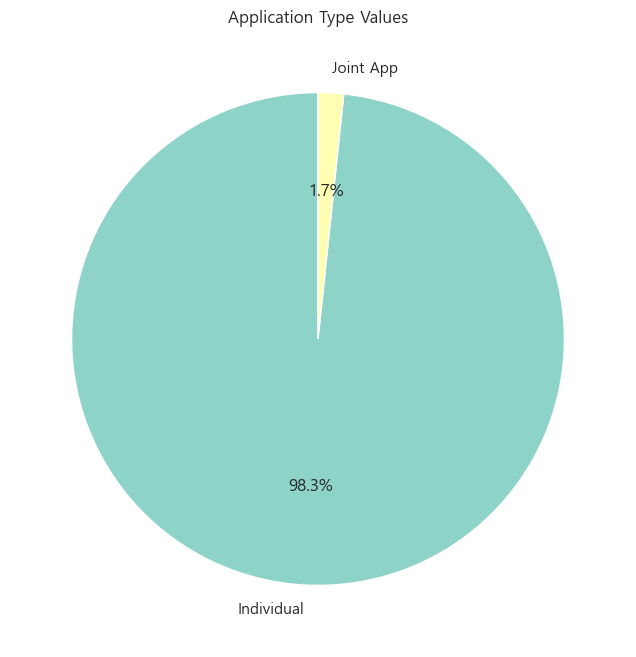

In [54]:
# pie
application_counts = df_main2['application_type'].value_counts()

# 파이 차트 그리기
plt.figure(figsize=(8,8))
plt.pie(application_counts, labels=application_counts.index, autopct='%1.1f%%', colors=sns.color_palette('Set3', len(application_counts)), startangle=90)
plt.title('Application Type Values')
plt.show()

## application_type 대출상환 여부

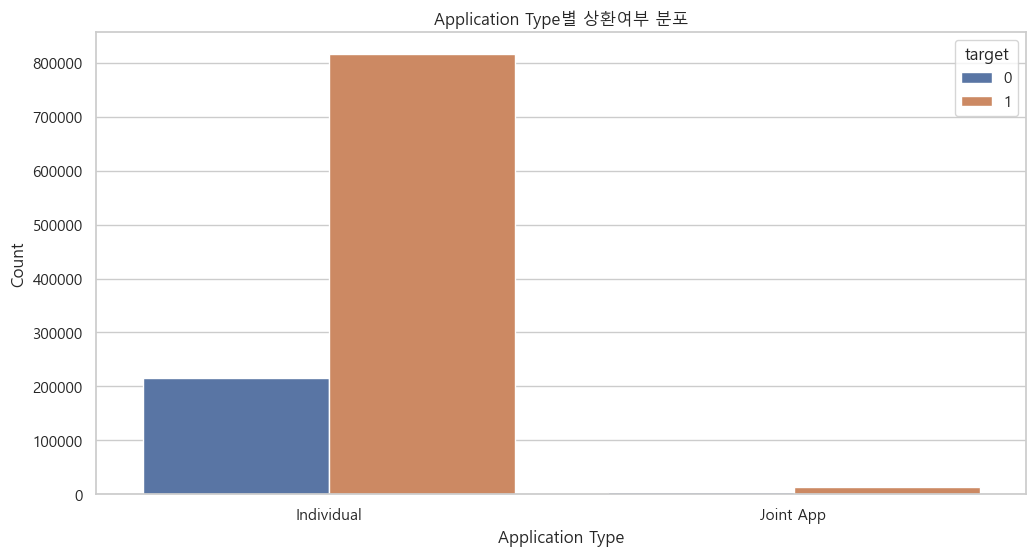

In [55]:
#applicaiton_type - target
plt.figure(figsize=(12, 6))
sns.countplot(data=df_main2, x='application_type', hue='target')
plt.title('Application Type별 상환여부 분포')
plt.xlabel('Application Type')
plt.ylabel('Count')
plt.show()

## term 분포 

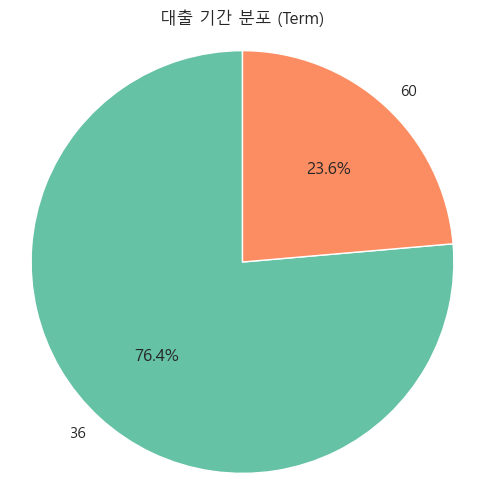

In [56]:
# 대출 기간 분포 계산
term_counts = df_main2['term'].value_counts()

# 원형 그래프
plt.figure(figsize=(6, 6))
plt.pie(term_counts, labels=term_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66c2a5', '#fc8d62'])
plt.title("대출 기간 분포 (Term)")
plt.axis('equal')  # 원형 유지
plt.show()

## term 상환여부 분포

C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\782306446.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\장정근\AppData\Local\Temp\ipykernel_12264\782306446.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


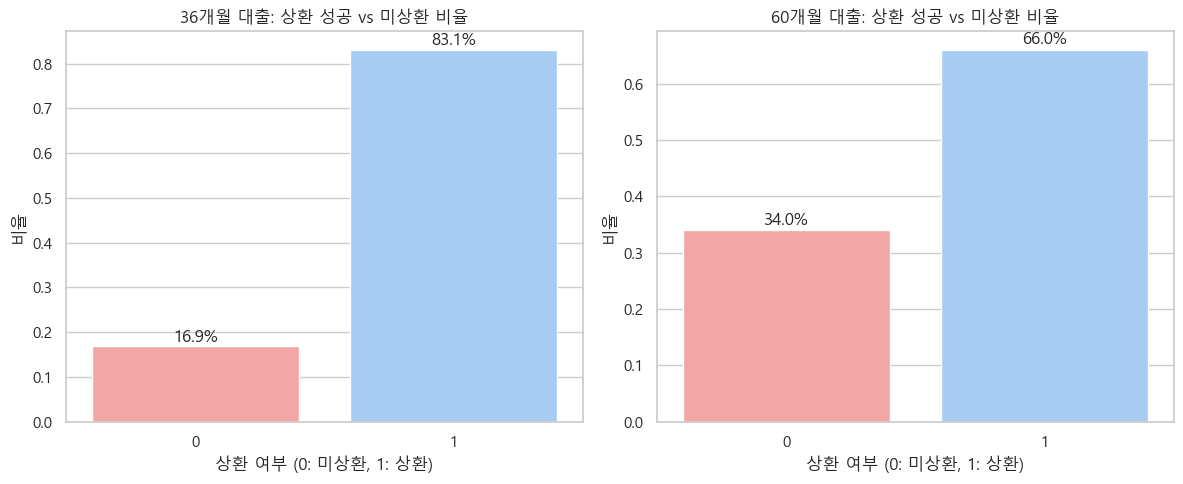

In [57]:
# 36개월 / 60개월 대출별로 분리
df_36 = df_main2[df_main2['term'] == 36]
df_60 = df_main2[df_main2['term'] == 60]

# 상환(1) vs 미상환(0) 비율 계산
prop_36 = df_36['target'].value_counts(normalize=True).sort_index()
prop_60 = df_60['target'].value_counts(normalize=True).sort_index()

# 시각화 설정
sns.set(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 36개월 Bar plot
sns.barplot(
    x=prop_36.index, 
    y=prop_36.values, 
    palette=['#FF9999', '#99CCFF'], 
    ax=axes[0]
)
axes[0].set_title("36개월 대출: 상환 성공 vs 미상환 비율")
axes[0].set_xlabel("상환 여부 (0: 미상환, 1: 상환)")
axes[0].set_ylabel("비율")
for i, v in enumerate(prop_36.values):
    axes[0].text(i, v + 0.01, f"{v:.1%}", ha='center')

# 60개월 Bar plot
sns.barplot(
    x=prop_60.index, 
    y=prop_60.values, 
    palette=['#FF9999', '#99CCFF'], 
    ax=axes[1]
)
axes[1].set_title("60개월 대출: 상환 성공 vs 미상환 비율")
axes[1].set_xlabel("상환 여부 (0: 미상환, 1: 상환)")
axes[1].set_ylabel("비율")
for i, v in enumerate(prop_60.values):
    axes[1].text(i, v + 0.01, f"{v:.1%}", ha='center')

plt.tight_layout()
plt.show()

## loan_to_income_ratio (대출금 대비 소득 비율)

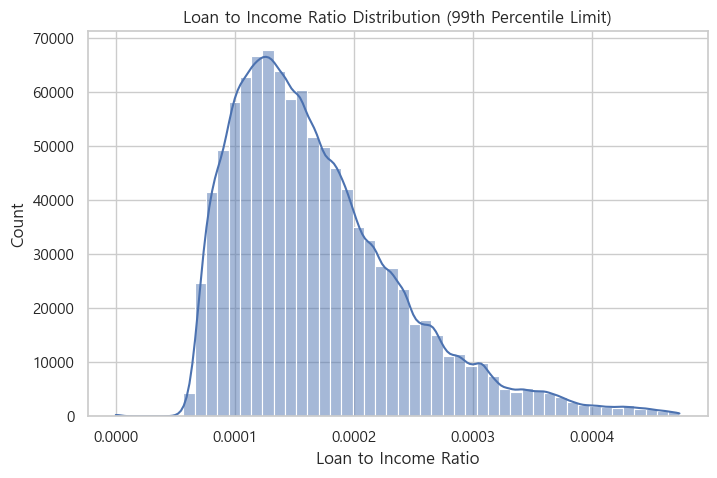

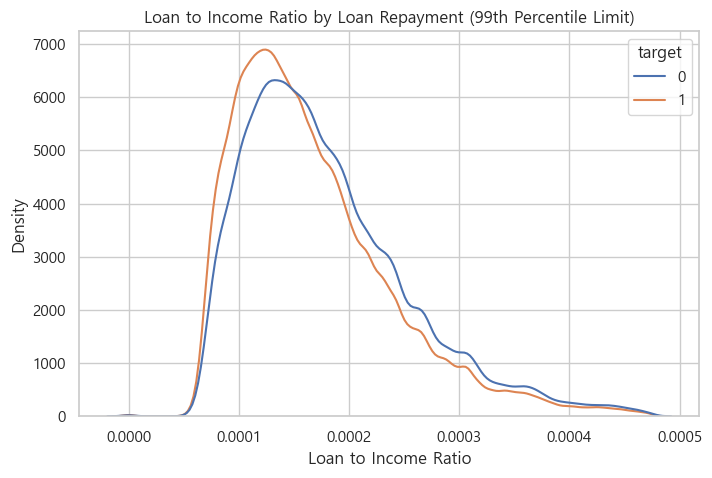

target
0   0.00
1   0.00
Name: loan_to_income_ratio, dtype: float64


In [58]:
# 방법 1: loan_to_income_ratio (대출금 대비 소득 비율)

df_main2['loan_to_income_ratio'] = df_main2['loan_amnt'] / df_main2['annual_inc']
df_main2['loan_to_income_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
df_main2['loan_to_income_ratio'].fillna(0, inplace=True)

# 1. 상위 1% 극단값 제거
q99 = df_main2['loan_to_income_ratio'].quantile(0.99)
df_main2 = df_main2[df_main2['loan_to_income_ratio'] <= q99]

# 2-1. 히스토그램 + 커널 밀도 (KDE 포함) - 분포 확인
plt.figure(figsize=(8,5))
sns.histplot(df_main2['loan_to_income_ratio'], bins=50, kde=True)
plt.title('Loan to Income Ratio Distribution (99th Percentile Limit)')
plt.xlabel('Loan to Income Ratio')
plt.ylabel('Count')
plt.show()

# 2-2. 상환 여부(target)별 Loan to Income 비율 밀도 비교
plt.figure(figsize=(8,5))
sns.kdeplot(data=df_main2, x='loan_to_income_ratio', hue='target', common_norm=False)
plt.title('Loan to Income Ratio by Loan Repayment (99th Percentile Limit)')
plt.xlabel('Loan to Income Ratio')
plt.ylabel('Density')
plt.show()

# 3. target(상환 여부)별 loan_to_income_ratio 평균 계산
mean_loan_to_income_by_target = df_main2.groupby('target')['loan_to_income_ratio'].mean()
print(mean_loan_to_income_by_target)

## loan_to_income_ratio 구간별 리스크 분석

In [ ]:
# 0. 파일명 설정
file_name = 'df_main2.csv'

# 1. 파일 존재 확인
if not os.path.exists(file_name):
    raise FileNotFoundError(f"'{file_name}' 파일이 현재 폴더에 없습니다. 파일 경로를 확인해주세요.")

# 2. 원본 파일 불러오기
df_main2 = pd.read_csv(file_name)

# 3. 복사본 생성
df_main2_copy = df_main2.copy()

# 4. loan_to_income_ratio 컬럼 생성
if 'loan_to_income_ratio' not in df_main2_copy.columns:
    df_main2_copy['loan_to_income_ratio'] = df_main2_copy['loan_amnt'] / df_main2_copy['annual_inc']
    df_main2_copy['loan_to_income_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
    df_main2_copy['loan_to_income_ratio'].fillna(0, inplace=True)

# 5. 현재 컬럼 목록 출력
print("\n현재 컬럼 목록:", df_main2_copy.columns.tolist())

# 6. 분석 코드 시작

# 6-1. 99% 분위수(상위 1%) 경계값 계산
q99 = df_main2_copy['loan_to_income_ratio'].quantile(0.99)

# 6-2. 구간 정의 및 데이터 필터링
bins = [0, 0.00005, 0.00010, 0.00015, 0.00020, q99]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

df_filtered = df_main2_copy[df_main2_copy['loan_to_income_ratio'] <= q99].copy()
df_filtered['loan_to_income_bin'] = pd.cut(df_filtered['loan_to_income_ratio'], bins=bins, labels=labels)

# 6-3. 구간별 성공률 및 실패율 계산
bin_summary = df_filtered.groupby('loan_to_income_bin')['target'].mean()
bin_failure_rate = 1 - bin_summary

# 6-4. 실패율 시각화 (Bar Plot)
plt.figure(figsize=(8, 5))
sns.barplot(x=bin_failure_rate.index, y=bin_failure_rate.values, palette="Reds")
plt.title('Loan Repayment Failure Rate by Loan to Income Ratio Bin')
plt.xlabel('Loan to Income Ratio Bin')
plt.ylabel('Failure Rate')
plt.ylim(0, bin_failure_rate.max() + 0.05)  # 최대값보다 조금 여유 있게
plt.tight_layout()
plt.show()

# 6-5. 구간별 데이터 건수 및 성공/실패 건수 집계
bin_counts = df_filtered['loan_to_income_bin'].value_counts().sort_index()
print("\n[구간별 데이터 건수]")
print(bin_counts)

bin_target_counts = df_filtered.groupby('loan_to_income_bin')['target'].value_counts().unstack()
print("\n[구간별 성공(1) / 실패(0) 건수]")
print(bin_target_counts)

# 6-6. 'Very Low' 제외 후 실패율/성공률/odds/odds-ratio 계산
bin_target_counts_no_very_low = bin_target_counts.drop('Very Low')

bin_target_counts_no_very_low['failure_rate'] = bin_target_counts_no_very_low[0] / (bin_target_counts_no_very_low[0] + bin_target_counts_no_very_low[1])
bin_target_counts_no_very_low['success_rate'] = bin_target_counts_no_very_low[1] / (bin_target_counts_no_very_low[0] + bin_target_counts_no_very_low[1])
bin_target_counts_no_very_low['failure_odds'] = bin_target_counts_no_very_low['failure_rate'] / bin_target_counts_no_very_low['success_rate']

very_low_odds = bin_target_counts_no_very_low.loc['Low', 'failure_odds']
bin_target_counts_no_very_low['odds_ratio_vs_low'] = bin_target_counts_no_very_low['failure_odds'] / very_low_odds

print("\n[구간별 실패율/성공률/오즈/오즈비]")
print(bin_target_counts_no_very_low[['failure_rate', 'success_rate', 'failure_odds', 'odds_ratio_vs_low']])

# 6-7. loan_to_income_bin × home_ownership별 실패율 분석
df_filtered_no_very_low = df_filtered[df_filtered['loan_to_income_bin'] != 'Very Low']

cross_tab = df_filtered_no_very_low.groupby(['loan_to_income_bin', 'home_ownership'])['target'].mean().unstack()
cross_tab_failure = 1 - cross_tab
cross_tab_failure = cross_tab_failure.dropna(how='all')

print("\n[구간별 주택소유형태별 실패율]")
print(cross_tab_failure)

# 6-8. 실패율 누적 그래프 (Stacked Bar Plot)
cross_tab_failure.plot(kind='bar', stacked=True, figsize=(10,6), colormap='tab10')
plt.title('Stacked Failure Rate by Loan to Income Bin and Home Ownership')
plt.xlabel('Loan to Income Bin')
plt.ylabel('Failure Rate')
plt.xticks(rotation=45)
plt.legend(title='Home Ownership', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## revol_balance_to_income (리볼빙 잔액 대비 소득 비율)

In [ ]:

# 1. 파일 존재 확인
if not os.path.exists(file_name):
    raise FileNotFoundError(f"'{file_name}' 파일이 현재 폴더에 없습니다. 파일 경로를 확인해주세요.")

# 2. 원본 파일 불러오기
df_main2 = pd.read_csv(file_name)

# 3. 복사본 생성
df_main2_copy = df_main2.copy()

# 4. loan_to_income_ratio 컬럼 생성
if 'loan_to_income_ratio' not in df_main2_copy.columns:
    df_main2_copy['loan_to_income_ratio'] = df_main2_copy['loan_amnt'] / df_main2_copy['annual_inc']
    df_main2_copy['loan_to_income_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
    df_main2_copy['loan_to_income_ratio'].fillna(0, inplace=True)

# 5. revol_balance_to_income 컬럼 생성
if 'revol_balance_to_income' not in df_main2_copy.columns:
    df_main2_copy['revol_balance_to_income'] = df_main2_copy['revol_bal'] / df_main2_copy['annual_inc']
    df_main2_copy['revol_balance_to_income'].replace([np.inf, -np.inf], np.nan, inplace=True)
    df_main2_copy['revol_balance_to_income'].fillna(0, inplace=True)

# 6. 현재 컬럼 목록 출력
print("\n현재 컬럼 목록:", df_main2_copy.columns.tolist())

# 7. revol_balance_to_income 분석 시작

# 7-1. 상위 1% 제거 (revol_balance_to_income 기준)
q99 = df_main2_copy['revol_balance_to_income'].quantile(0.99)
filtered_data = df_main2_copy[df_main2_copy['revol_balance_to_income'] <= q99]
filtered_revol_balance = filtered_data['revol_balance_to_income']

# 7-2. 로그 변환 분포 시각화
plt.figure(figsize=(10, 6))
plt.hist(np.log1p(filtered_revol_balance), bins=30, edgecolor='black')
plt.title('Log-Transformed Revolving Balance to Income Ratio (Top 1% Removed)')
plt.xlabel('log(1 + Revolving Balance to Income Ratio)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 7-3. 상환 여부(target)에 따른 분포 비교 (겹쳐진 히스토그램)
plt.figure(figsize=(12, 6))

# 미상환 (target = 0)
plt.hist(filtered_data[filtered_data['target'] == 0]['revol_balance_to_income'], 
         bins=30, alpha=0.5, label='Not Fully Paid (target=0)', color='red', edgecolor='black')

# 상환 (target = 1)
plt.hist(filtered_data[filtered_data['target'] == 1]['revol_balance_to_income'], 
         bins=30, alpha=0.5, label='Fully Paid (target=1)', color='blue', edgecolor='black')

plt.title('Revolving Balance to Income Ratio by Repayment Status (Top 1% Removed)')
plt.xlabel('Revolving Balance to Income Ratio')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# 7-4. 평균 및 중앙값 비교
mean_values = filtered_data.groupby('target')['revol_balance_to_income'].mean()
median_values = filtered_data.groupby('target')['revol_balance_to_income'].median()

print("\n평균 Revolving Balance to Income Ratio (target별):")
print(mean_values)

print("\n중앙값 Revolving Balance to Income Ratio (target별):")
print(median_values)


## 수치형 변수간 상관관계

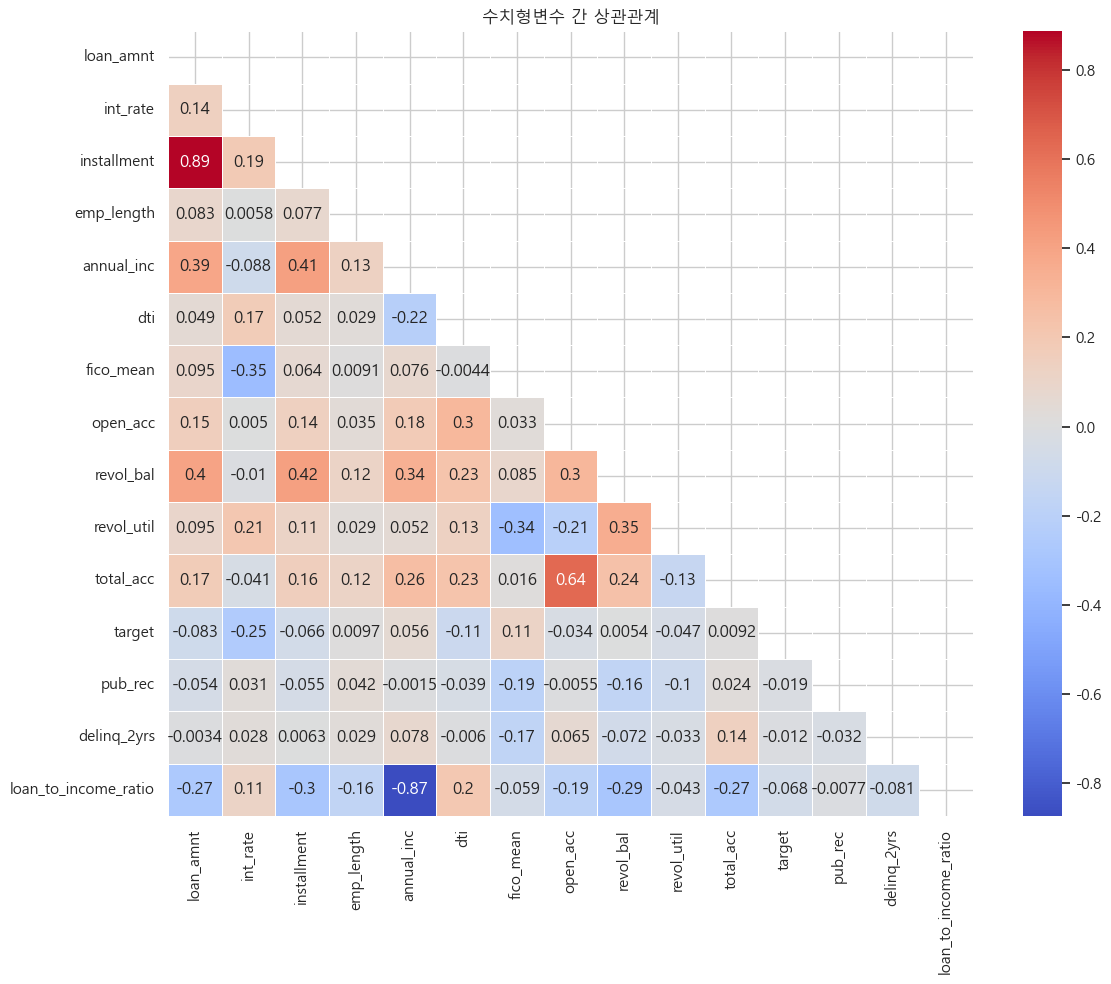

In [63]:
#4. 수치형변수간 상관관계
# 수치형 변수만 추출 
num_cols = df_main2.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 상관계수 행렬 계산
corr_matrix = df_main2[num_cols].corr()

# 히트맵
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # 대각선 기준 위 삼각형 mask
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
            linewidths=0.5, mask=mask)
plt.title('수치형변수 간 상관관계')
plt.tight_layout()
plt.show()

In [65]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# 데이터프레임으로 변환
X_for_vif = X_numeric.copy()

# VIF 계산
vif = pd.DataFrame()
vif["feature"] = X_for_vif.columns
vif["VIF"] = [variance_inflation_factor(X_for_vif.values, i) for i in range(X_for_vif.shape[1])]

# 정렬
vif.sort_values(by="VIF", ascending=False, inplace=True)
vif

ModuleNotFoundError: No module named 'statsmodels'

## --------------------- 모델링 ---------------------

In [66]:
select_cols = ['loan_amnt','term','int_rate','sub_grade','emp_length','home_ownership',
               'annual_inc','verification_status','purpose','dti','fico_mean','open_acc','revol_bal',
               'revol_util','total_acc','target','addr_state','application_type','pub_rec','delinq_2yrs'
               ]

df_main2 = df_main[select_cols].copy()

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from xgboost import XGBClassifier

## XGBoost + 언더샘플링

Train: (726884, 21), Val: (155762, 21), Test: (155762, 21)


c:\Anaconda3\envs\py38\lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Anaconda3\envs\py38\lib\site-packages\xgboost\core.py:158: UserWarning: [14:12:56] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



=== Validation Performance ===
              precision    recall  f1-score   support

           0     0.3281    0.6658    0.4396     32543
           1     0.8788    0.6398    0.7405    123219

    accuracy                         0.6453    155762
   macro avg     0.6034    0.6528    0.5900    155762
weighted avg     0.7637    0.6453    0.6776    155762

Validation Confusion Matrix:
[[21668 10875]
 [44378 78841]]
Validation ROC AUC: 0.711051671909658


c:\Anaconda3\envs\py38\lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
c:\Anaconda3\envs\py38\lib\site-packages\xgboost\core.py:158: UserWarning: [14:13:01] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



=== Test Performance ===
              precision    recall  f1-score   support

           0     0.3278    0.6657    0.4392     32543
           1     0.8787    0.6394    0.7402    123219

    accuracy                         0.6449    155762
   macro avg     0.6032    0.6525    0.5897    155762
weighted avg     0.7636    0.6449    0.6773    155762

Test Confusion Matrix:
[[21664 10879]
 [44435 78784]]
Test ROC AUC: 0.7108865286713193


<Figure size 600x500 with 0 Axes>

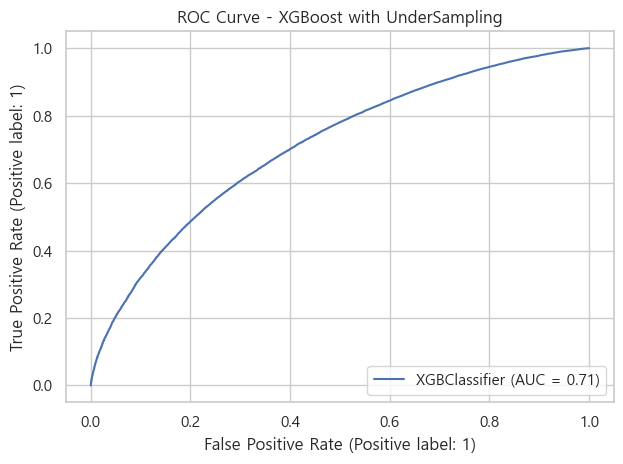

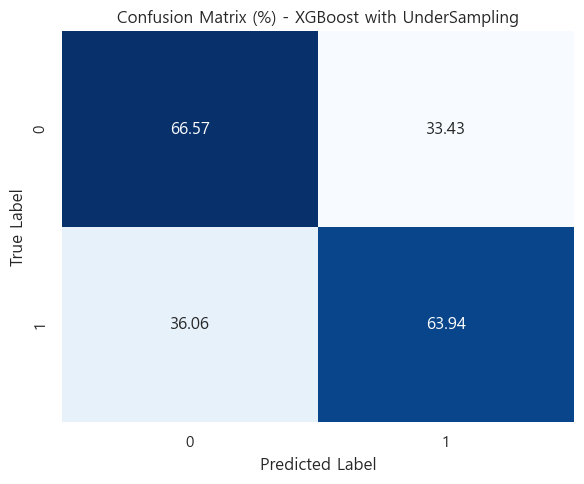

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier

# 1) 데이터 준비
X = df_main2.drop(columns=["target"])
y = df_main2["target"]

# 2) Train/Validation/Test 분할
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, stratify=y, test_size=0.15, random_state=42
)

val_ratio = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp, y_train_temp,
    stratify=y_train_temp,
    test_size=val_ratio,
    random_state=42
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# 3) 전처리 파이프라인 정의
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), categorical_cols)
])

# 전처리만 파이프라인으로
preprocessing_pipeline = Pipeline([
    ("pre", preprocessor)
])

# 4) X_train, X_val 전처리
X_train_preprocessed = preprocessing_pipeline.fit_transform(X_train)
X_val_preprocessed = preprocessing_pipeline.transform(X_val)

# 5) 언더샘플링 적용
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train_preprocessed, y_train)

# 6) 모델 학습 (XGBoost)
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

model.fit(X_train_resampled, y_train_resampled)

# 7) Validation 평가
y_val_pred = model.predict(X_val_preprocessed)
y_val_proba = model.predict_proba(X_val_preprocessed)[:, 1]

print("\n=== Validation Performance ===")
print(classification_report(y_val, y_val_pred, digits=4))
print("Validation Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))
print("Validation ROC AUC:", roc_auc_score(y_val, y_val_proba))

# 8) 최종 모델 (Train+Val 합치기)
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

X_train_val_preprocessed = preprocessing_pipeline.fit_transform(X_train_val)
X_test_preprocessed = preprocessing_pipeline.transform(X_test)

X_train_val_resampled, y_train_val_resampled = rus.fit_resample(X_train_val_preprocessed, y_train_val)

# 재학습
model.fit(X_train_val_resampled, y_train_val_resampled)

# 9) Test 평가
y_test_pred = model.predict(X_test_preprocessed)
y_test_proba = model.predict_proba(X_test_preprocessed)[:, 1]

print("\n=== Test Performance ===")
print(classification_report(y_test, y_test_pred, digits=4))
print("Test Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_test_proba))

# 10) Test ROC Curve 시각화
plt.figure(figsize=(6,5))
RocCurveDisplay.from_estimator(model, X_test_preprocessed, y_test)
plt.title("ROC Curve - XGBoost with UnderSampling")
plt.tight_layout()
plt.show()



# 11) Confusion Matrix를 비율(%)로 시각화
cm = confusion_matrix(y_test, y_test_pred)

# 비율(%)로 변환
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Heatmap 시각화
plt.figure(figsize=(6,5))
sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (%) - XGBoost with UnderSampling')
plt.tight_layout()
plt.show()

## LightGBM + scale_pos_weight(class가중치 자동조정 옵션, 불균형 처리)

In [61]:
# [1] 데이터 불러오기
X = df.drop(columns='target')
y = df['target']

print(X.shape, y.shape)
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# [2 ] 데이터 나누기 (train 70%, val 15%, test 15%)
# Train으로 학습 + Validation으로 검증 + Test로 최종 성능을 평가
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
# [3] 데이터 전처리 + 파생변수 추가 
import matplotlib.pyplot as plt
import seaborn as sns

# 파생변수 추가
def add_features(X):
    X = X.copy()
    X['loan_to_income'] = X['loan_amnt'] / (X['annual_inc'] + 1)  # 나누기 0 방지
    return X

X_train = add_features(X_train)
X_val = add_features(X_val)
X_test = add_features(X_test)

# # 분포 확인
# plt.figure(figsize=(6,4))
# sns.histplot(X_train['loan_to_income'], kde=True)
# plt.title('Loan to Income Distribution (Train)')
# plt.show()

#필요하면 파생변수 전처리
def preprocess_features(X):
    X = X.copy()
    categorical_cols = X.select_dtypes(include='object').columns
    for col in categorical_cols:
        X[col] = X[col].astype('category')
    return X

X_train = preprocess_features(X_train)
X_val = preprocess_features(X_val)
X_test = preprocess_features(X_test)

# [4] 모델 선언 + 튜닝 : LightGBM 
# 클래스 불균형 가중치 계산
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"\\n클래스 가중치: {scale_pos_weight:.2f} (0: {y_train.value_counts()[0]}, 1: {y_train.value_counts()[1]})")

# LightGBM 모델 선언
lgb_pipeline = Pipeline([
    ('model', lgb.LGBMClassifier(
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        n_estimators=1000,  # 충분히 큰 값 + early stopping
        verbose=-1
    ))
])



# 하이퍼파라미터 후보 정리
param_grid = {
    'model__num_leaves': [31, 63, 127],
    'model__learning_rate': [0.01, 0.05],
    'model__max_depth': [5, 7, 10],
    'model__min_child_samples': [20, 30],
    'model__reg_alpha': [0.1, 0.5],
    'model__reg_lambda': [0.1, 0.5]
}


# Grid Search: 최고의 모델 찾아내기
grid_search = GridSearchCV(
    estimator=lgb_pipeline,
    param_grid=param_grid,
    scoring='recall',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=2
)

# 조기 종료 장치 : 과적합 방지
early_stopping = lgb.early_stopping(stopping_rounds=50, verbose=False)

# 모델 학습
grid_search.fit(
    X_train, y_train,
    model__eval_set=[(X_val, y_val)], #검증 데이터
    model__callbacks=[early_stopping]
)

# 최적의 모델 추출
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = grid_search.best_score_
best_model_score = best_model.score(X_val, y_val)
print(f"최적의 하이퍼파라미터: {best_params}")      

# 최적의 하이퍼파라미터 나온 결과 대로 모델 선언
import lightgbm as lgb
from lightgbm import early_stopping


# 최적 하이퍼파라미터로 모델 선언
lgb_model = lgb.LGBMClassifier(
    random_state=42,
    scale_pos_weight=scale_pos_weight ,  # 불균형 데이터 처리
    learning_rate=0.01,
    max_depth=5,
    min_child_samples=20,
    num_leaves=31,
    reg_alpha=0.1,
    reg_lambda=0.1,
    n_estimators=1000,
    verbose=-1


)
# 조기 종료 장치 : 과적합 방지
early_stopping = lgb.early_stopping(stopping_rounds=50, verbose=False)  

# 모델 학습
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='recall'
)
# 예측 수행
y_pred = lgb_model.predict(X_test)
y_proba = lgb_model.predict_proba(X_test)[:,1]

# 성능 평가
print("\n=== 최종 테스트셋 성능 ===")
print(classification_report(y_test, y_pred))
print("=== 혼동 행렬 ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR AUC: {average_precision_score(y_test, y_proba):.4f}")
# 저장
import os
import pandas as pd
import numpy as np
from sklearn.metrics import (
    balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss, roc_curve
)

# 1) 예측값 준비 (pipeline, X_test, y_test는 이미 정의됨)
y_pred  = lgb_model.predict(X_test)
y_proba = lgb_model.predict_proba(X_test)[:,1]

# 2) 지표 계산
precs = precision_score(y_test, y_pred, average=None, labels=[0,1])
recs  = recall_score(y_test, y_pred, average=None, labels=[0,1])
f1s   = f1_score(y_test, y_pred, average=None, labels=[0,1])
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc  = average_precision_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)
ks_stat    = np.max(tpr - fpr)
gini       = 2*roc_auc - 1
brier      = brier_score_loss(y_test, y_proba)
bal_acc    = balanced_accuracy_score(y_test, y_pred)

# 3) 결과 딕셔너리 생성
new_result = {
    'Model': 'LightGBM',
    'Precision_0': precs[0], 'Recall_0': recs[0], 'F1_0': f1s[0],
    'Precision_1': precs[1], 'Recall_1': recs[1], 'F1_1': f1s[1],
    'PR AUC': pr_auc, 'ROC AUC': roc_auc,
    'Balanced Accuracy': bal_acc,
    'KS-statistic': ks_stat, 'Gini Coef': gini,
    'Brier Score': brier
}

# 결과 해석
# feature_importance 어떤 변수가 중요한지 확인

feature_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgb_model.feature_importances_
}).sort_values('Importance', ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp.head(20))
plt.title("Top 20 Feature Importances")
plt.show()


# 2. SHAP Summary (0번 클래스 중심으로)
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test)

plt.title("SHAP Feature Impacts")
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

# # 3. SHAP Dependence Plot (특정 feature에 대한 영향력)
# shap.dependence_plot(
#     feature="annual_inc",
#     shap_values=shap_values[1],
#     features=X_test,
#     interaction_index=None,
#     show=True
# )       


# 4. Confusion Matrix Heatmap
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


(1048773, 4) (1048773,)
Train: (734141, 4), Val: (157316, 4), Test: (157316, 4)


KeyError: 'loan_amnt'

## CatBoost + Class_weights(불균형 처리)

In [ ]:
# X, y
X = df_main2[all_features]
y = df_main2['target']

# 데이터 분할
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.1765, stratify=y_trainval, random_state=42)

# 언더샘플링 적용
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

# CatBoost 모델
model_under = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=100,
    allow_writing_files=False
)

# 학습
model_under.fit(X_train_under, y_train_under, cat_features=cat_cols, eval_set=(X_val, y_val))

# 평가
y_pred = model_under.predict(X_test)
y_proba = model_under.predict_proba(X_test)[:, 1]

print("=== [언더샘플링 + CatBoost] 결과 ===")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")